In [1]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
from sklearn.linear_model import LinearRegression
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

C:\Users\x12la\AppData\Local\Temp\ipykernel_5136\3882779582.py:8: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  from geopandas.tools import sjoin


<h1> Load data 

In [2]:
# CMAQ lat/lon datafile
d03 = Dataset('C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc')
cmaq_lon,cmaq_lat = np.array(d03['lon']),np.array(d03['lat'])
cmaq_llat,cmaq_ulat,cmaq_llon,cmaq_ulon=cmaq_lat.min(), cmaq_lat.max(), cmaq_lon.min(), cmaq_lon.max()

In [3]:
#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

#primary roads
primary_roads = gpd.read_file('C:/Users/x12la/Desktop/Scripts/tl_2016_us_primaryroads.shp')
primary_roads = primary_roads.to_crs('EPSG:4326')

In [ ]:
## Upload annual average concentration shapefiles
base = gpd.read_file('COMBINE_ACONC_BASE_July2023_Average.shp')
base = base.to_crs('EPSG:4326')

idling = gpd.read_file('COMBINE_ACONC_LOCUSIdling_HDVSpatial_July2023_Average.shp')
idling = idling.to_crs('EPSG:4326')

renewal = gpd.read_file('COMBINE_ACONC_Renewal_July2023_Average.shp')
renewal = renewal.to_crs('EPSG:4326')

zeropre2010s =  gpd.read_file('COMBINE_ACONC_ZeroPre2010s_July2023_average.shp')
zeropre2010s = zeropre2010s.to_crs('EPSG:4326')

In [ ]:
## Upload annual average MDA8O3concentration  shapefiles
base_o3 = gpd.read_file('MDA8O3_July2023_BASE_Average.shp')
base_o3 = base_o3.to_crs('EPSG:4326')

idling_o3 = gpd.read_file('MDA8O3_July2023_LOCUSIdling_HDVSpatial_Average.shp')
idling_o3 = idling_o3.to_crs('EPSG:4326')

renewal_o3 = gpd.read_file('MDA8O3_July2023_Renewal_Average.shp')
renewal_o3 = renewal_o3.to_crs('EPSG:4326')

zeropre2010s_o3 =  gpd.read_file('MDA8O3_July2023_ZeroPre2010s_Average.shp')
zeropre2010s_o3 = zeropre2010s_o3.to_crs('EPSG:4326')

In [ ]:
#Clip geopandas files to CMAP
cmap_roads = gpd.clip(primary_roads, cmap_cty.to_crs('EPSG:4326'))
cmap_base = gpd.clip(base, cmap_cty.to_crs('EPSG:4326'))
cmap_idling = gpd.clip(idling, cmap_cty.to_crs('EPSG:4326'))
cmap_renewal = gpd.clip(renewal, cmap_cty.to_crs('EPSG:4326'))
cmap_zeropre2010s = gpd.clip(zeropre2010s, cmap_cty.to_crs('EPSG:4326'))

cmap_base_o3 = gpd.clip(base_o3, cmap_cty.to_crs('EPSG:4326'))
cmap_idling_o3 = gpd.clip(idling_o3, cmap_cty.to_crs('EPSG:4326'))
cmap_renewal_o3 = gpd.clip(renewal_o3, cmap_cty.to_crs('EPSG:4326'))
cmap_zeropre2010s_o3 = gpd.clip(zeropre2010s_o3, cmap_cty.to_crs('EPSG:4326'))

<h1> Plot All 

In [ ]:
N_BINS = 16

# pollutant plotting setup
plot_config = {
    "NO2": {
        "cmap_name": "viridis",
        "title": "NO$_2$",
        "label": "NO$_2$",
    },
    "PM25_TOT": {
        "cmap_name": "plasma",
        "title": "PM$_{2.5}$ Total",
        "label": "PM$_{2.5}$ Total",
    },
    "PM25_EC": {
        "cmap_name": "magma",
        "title": "PM$_{2.5}$ EC",
        "label": "PM$_{2.5}$ EC",
    },
    "O3": {
        "cmap_name": "cividis",
        "title": "O$_3$",
        "label": "O$_3$",
    },
#    "NH3": {
#         "cmap_name": "inferno",
#         "title": "NH$_3$",
#         "label": "NH$_3$",
#     }    
}

scenario_gdfs = {
    "Base": cmap_base,
    "LOCUS + HDV MOD": cmap_idling,
    "Renewal": cmap_renewal,
    "Zero Pre2010": cmap_zeropre2010s 
}

pollutants = ["NO2", "PM25_TOT", "PM25_EC", "O3"] #, "NH3"]
scenario_names = ["Base", "LOCUS + HDV MOD", "Renewal", "Zero Pre2010"]

# -----------------------------
pollutant_styles = {}

for pol in pollutants:
    vals_all = []
    for scen in scenario_names:
        vals = scenario_gdfs[scen][pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vals_all.append(vals)

    vals_all = np.concatenate(vals_all)

    vmin = np.nanmin(vals_all)
    vmax = np.nanmax(vals_all)

    vmin = np.quantile(vals_all, 0.01)
    vmax = np.quantile(vals_all, 0.99)
    
    # if all values are identical, pad slightly so BoundaryNorm works
    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    cmap_disc = ListedColormap(
        plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))
    )
    bounds = np.linspace(vmin, vmax, N_BINS + 1)
    norm = BoundaryNorm(bounds, cmap_disc.N)

    pollutant_styles[pol] = {
        "vmin": vmin,
        "vmax": vmax,
        "bounds": bounds,
        "cmap": cmap_disc,
        "norm": norm
    }

C:\Users\x12la\AppData\Local\Temp\ipykernel_5368\3601131199.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))


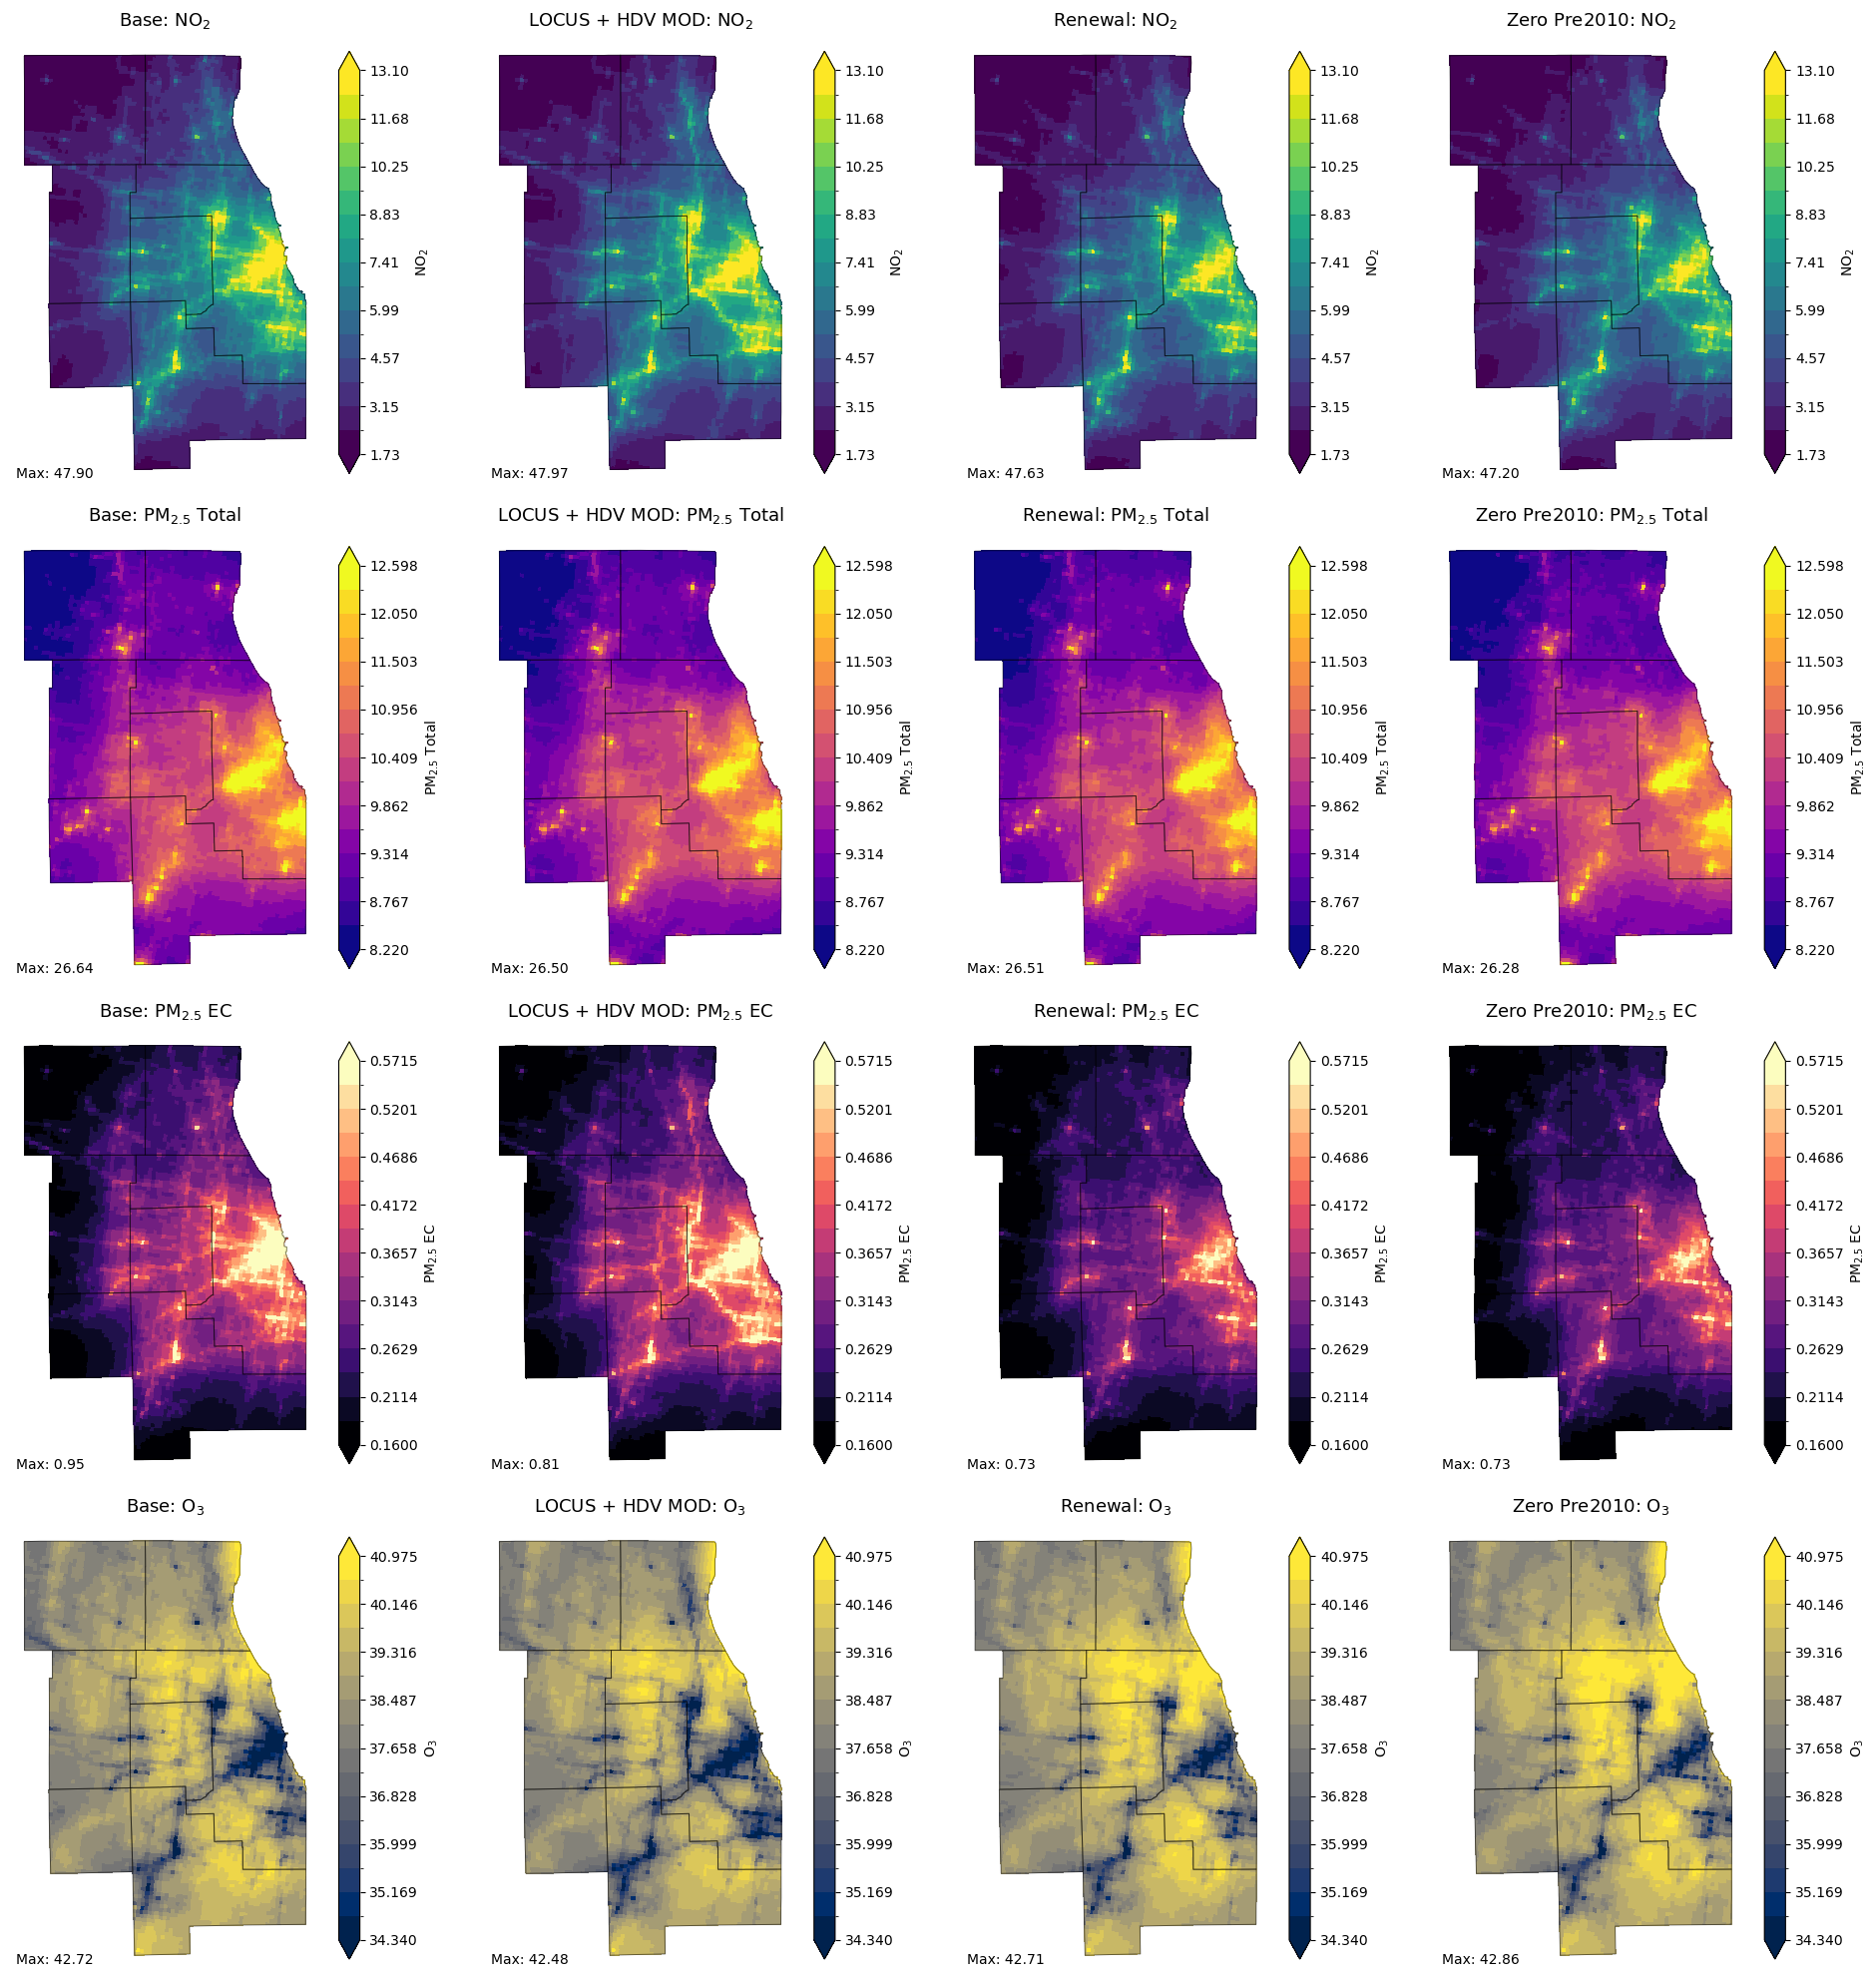

In [26]:
# -----------------------------
# plot absolute concentrations 
# -----------------------------
fig, axs = plt.subplots(
    nrows=4, ncols=4,   
    figsize=(20, 20), 
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for i, pol in enumerate(pollutants):
    for j, scen in enumerate(scenario_names):
        ax = axs[i, j]
        gdf = scenario_gdfs[scen]

        style = pollutant_styles[pol]
        cmap_disc = style["cmap"]
        norm = style["norm"]
        bounds = style["bounds"]

        gdf.plot(
            column=pol,
            ax=ax,
            cmap=cmap_disc,
            norm=norm,
            edgecolor="none",
            antialiased=False
        )

        cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)
        ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=13)
        ax.set_axis_off()

        # colorbar for each panel
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
        sm._A = []
        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            boundaries=bounds,
            ticks=bounds[::2],  
            spacing="proportional", extend='both'
            
        )
        cbar.set_label(plot_config[pol]["label"], fontsize=10)

        # annotate max at lower-left
        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vmax_panel = float(np.nanmax(vals))

        ax.text(
            0.02, 0.02,
            f"Max: {vmax_panel:.2f}",
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            color="black",
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                boxstyle="round,pad=0.25",
                linewidth=0
            )
        )

plt.tight_layout()
plt.show()

C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\3394778485.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\3394778485.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\3394778485.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cm

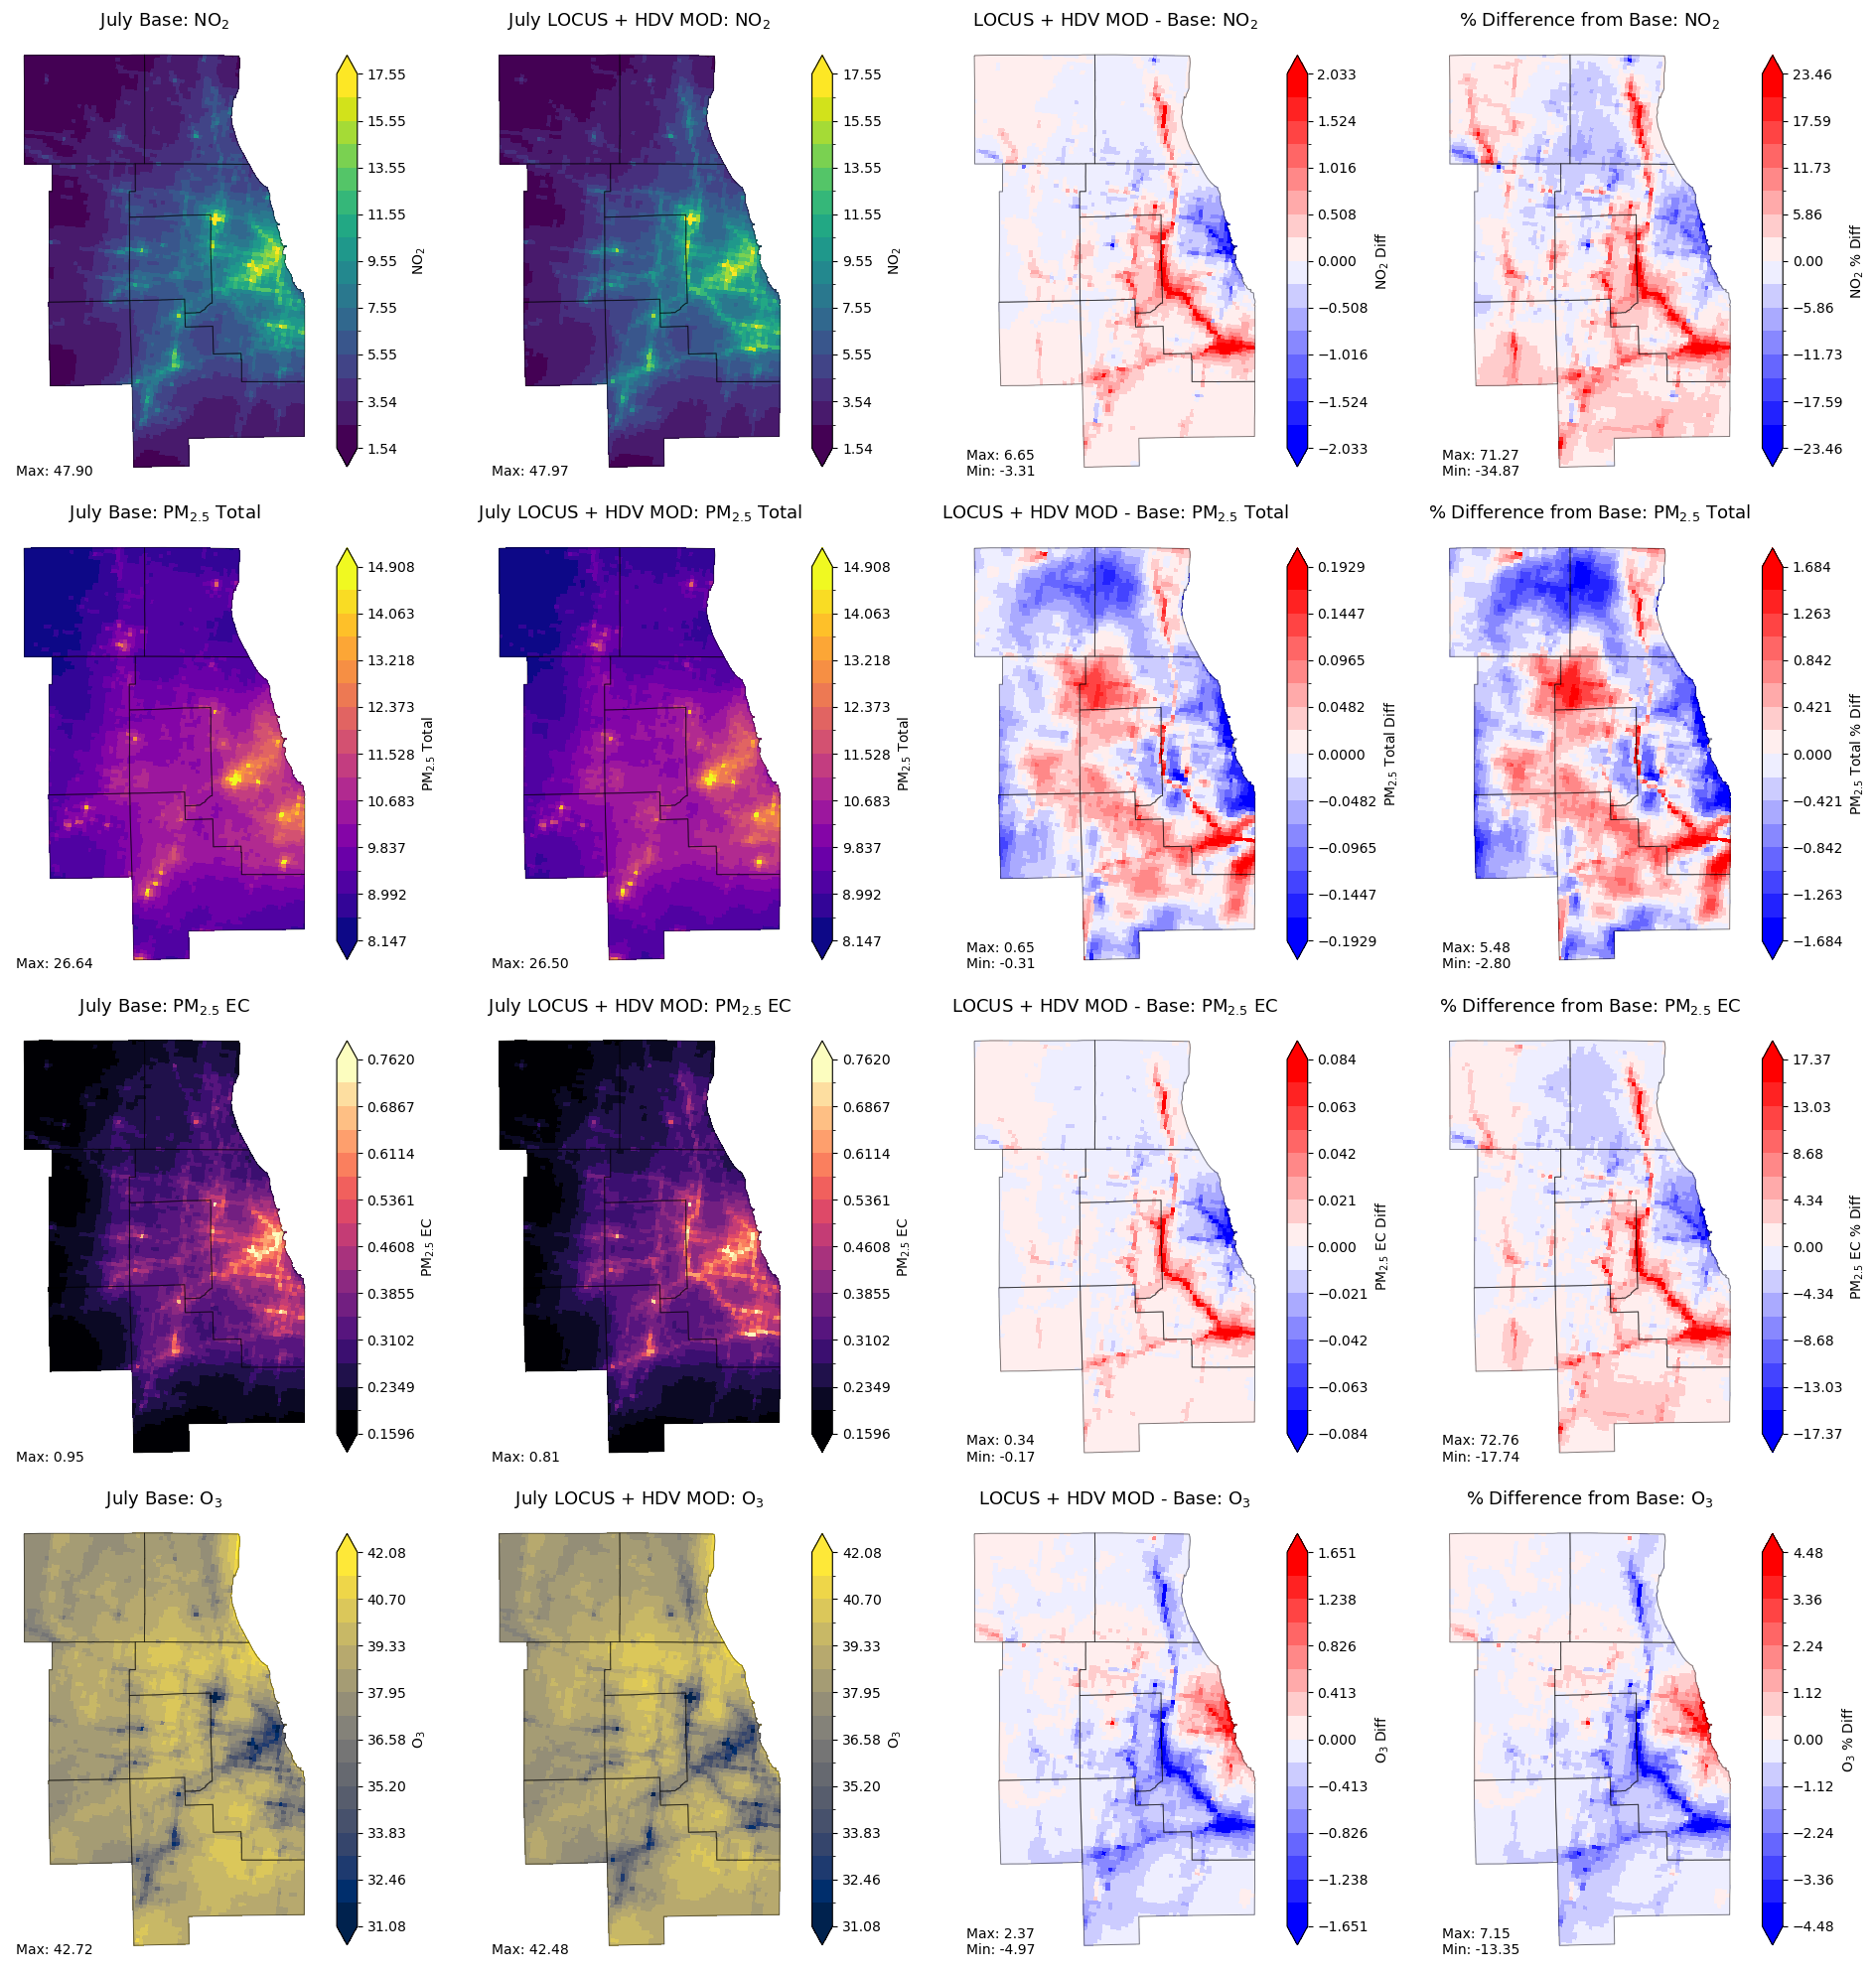

In [8]:
# ---------------------------------------------------
# Base & LOCUS Idling + HDV Mod comparison 
# ---------------------------------------------------
abs_styles = {}

for pol in pollutants:
    vals_all = []

    for gdf in [cmap_base, cmap_idling]:
        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vals_all.append(vals)

    vals_all = np.concatenate(vals_all)

    vmin = np.quantile(vals_all, 0.001)
    vmax = np.quantile(vals_all, 0.999)

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    cmap_disc = ListedColormap(
        plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))
    )
    bounds = np.linspace(vmin, vmax, N_BINS + 1)
    norm = BoundaryNorm(bounds, cmap_disc.N)

    abs_styles[pol] = {
        "vmin": vmin,
        "vmax": vmax,
        "bounds": bounds,
        "cmap": cmap_disc,
        "norm": norm
    }

# ---------------------------------------------------
# build styles for difference panels
#   col 3 = idling - base
#   col 4 = % diff
# ---------------------------------------------------
diff_styles = {}

for pol in pollutants:
    base_vals = cmap_base[pol].astype(float).to_numpy()
    idling_vals = cmap_idling[pol].astype(float).to_numpy()

    diff_vals = idling_vals - base_vals
    pct_vals = np.where(base_vals != 0, (diff_vals / base_vals) * 100.0, np.nan)

    diff_vals_finite = diff_vals[np.isfinite(diff_vals)]
    pct_vals_finite = pct_vals[np.isfinite(pct_vals)]

    # symmetric bounds so white is centered at zero
    diff_lim = np.quantile(np.abs(diff_vals_finite), 0.99)
    pct_lim = np.quantile(np.abs(pct_vals_finite), 0.99)

    if np.isclose(diff_lim, 0):
        diff_lim = 1e-6
    if np.isclose(pct_lim, 0):
        pct_lim = 1e-6

    diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
    pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)

    diff_cmap = ListedColormap(
        plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
    )
    pct_cmap = ListedColormap(
        plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
    )

    diff_norm = BoundaryNorm(diff_bounds, diff_cmap.N)
    pct_norm = BoundaryNorm(pct_bounds, pct_cmap.N)

    diff_styles[pol] = {
        "diff_bounds": diff_bounds,
        "diff_cmap": diff_cmap,
        "diff_norm": diff_norm,
        "pct_bounds": pct_bounds,
        "pct_cmap": pct_cmap,
        "pct_norm": pct_norm,
    }

# ---------------------------------------------------
# make plotting GeoDataFrames
# ---------------------------------------------------
plot_base = cmap_base.copy()
plot_idling = cmap_idling.copy()
plot_diff = cmap_idling.copy()
plot_pct = cmap_idling.copy()

for pol in pollutants:
    plot_diff[pol] = cmap_idling[pol].astype(float) - cmap_base[pol].astype(float)
    plot_pct[pol] = np.where(
        cmap_base[pol].astype(float) != 0,
        ((cmap_idling[pol].astype(float) - cmap_base[pol].astype(float)) / cmap_base[pol].astype(float)) * 100.0,
        np.nan
    )

scenario_gdfs = {
    "July Base": plot_base,
    "July LOCUS + HDV MOD": plot_idling,
    "LOCUS + HDV MOD - Base": plot_diff,
    "% Difference from Base": plot_pct,
}

scenario_names = [
    "July Base",
    "July LOCUS + HDV MOD",
    "LOCUS + HDV MOD - Base",
    "% Difference from Base"
]

# ---------------------------------------------------
# plot
# ---------------------------------------------------
fig, axs = plt.subplots(
    nrows=len(pollutants),
    ncols=4,
    figsize=(20, 20),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for i, pol in enumerate(pollutants):
    for j, scen in enumerate(scenario_names):
        ax = axs[i, j]
        gdf = scenario_gdfs[scen]

        # choose style by column
        if j in [0, 1]:
            style = abs_styles[pol]
            cmap_disc = style["cmap"]
            norm = style["norm"]
            bounds = style["bounds"]
            extend_opt = "both"
        elif j == 2:
            style = diff_styles[pol]
            cmap_disc = style["diff_cmap"]
            norm = style["diff_norm"]
            bounds = style["diff_bounds"]
            extend_opt = "both"
        else:
            style = diff_styles[pol]
            cmap_disc = style["pct_cmap"]
            norm = style["pct_norm"]
            bounds = style["pct_bounds"]
            extend_opt = "both"

        gdf.plot(
            column=pol,
            ax=ax,
            cmap=cmap_disc,
            norm=norm,
            edgecolor="none",
            antialiased=False
        )

        cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)
        # domain_tracts.boundary.plot(ax=ax, color="k", alpha=0.15, linewidth=0.2)

        ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=13)
        ax.set_axis_off()

        # panel colorbar
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
        sm._A = []
        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            boundaries=bounds,
            ticks=bounds[::2],
            spacing="proportional",
            extend=extend_opt
        )

        if j == 3:
            cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=10)
        elif j == 2:
            cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=10)
        else:
            cbar.set_label(plot_config[pol]["label"], fontsize=10)

        # annotations
        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]

        vmax_panel = float(np.nanmax(vals))
        vmin_panel = float(np.nanmin(vals))

        if j in [0, 1]:
            annot_text = f"Max: {vmax_panel:.2f}"
        else:
            annot_text = f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"

        ax.text(
            0.02, 0.02,
            annot_text,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            color="black",
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                boxstyle="round,pad=0.25",
                linewidth=0
            )
        )

plt.tight_layout()
plt.show()

C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\2637850470.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\2637850470.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\2637850470.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cm

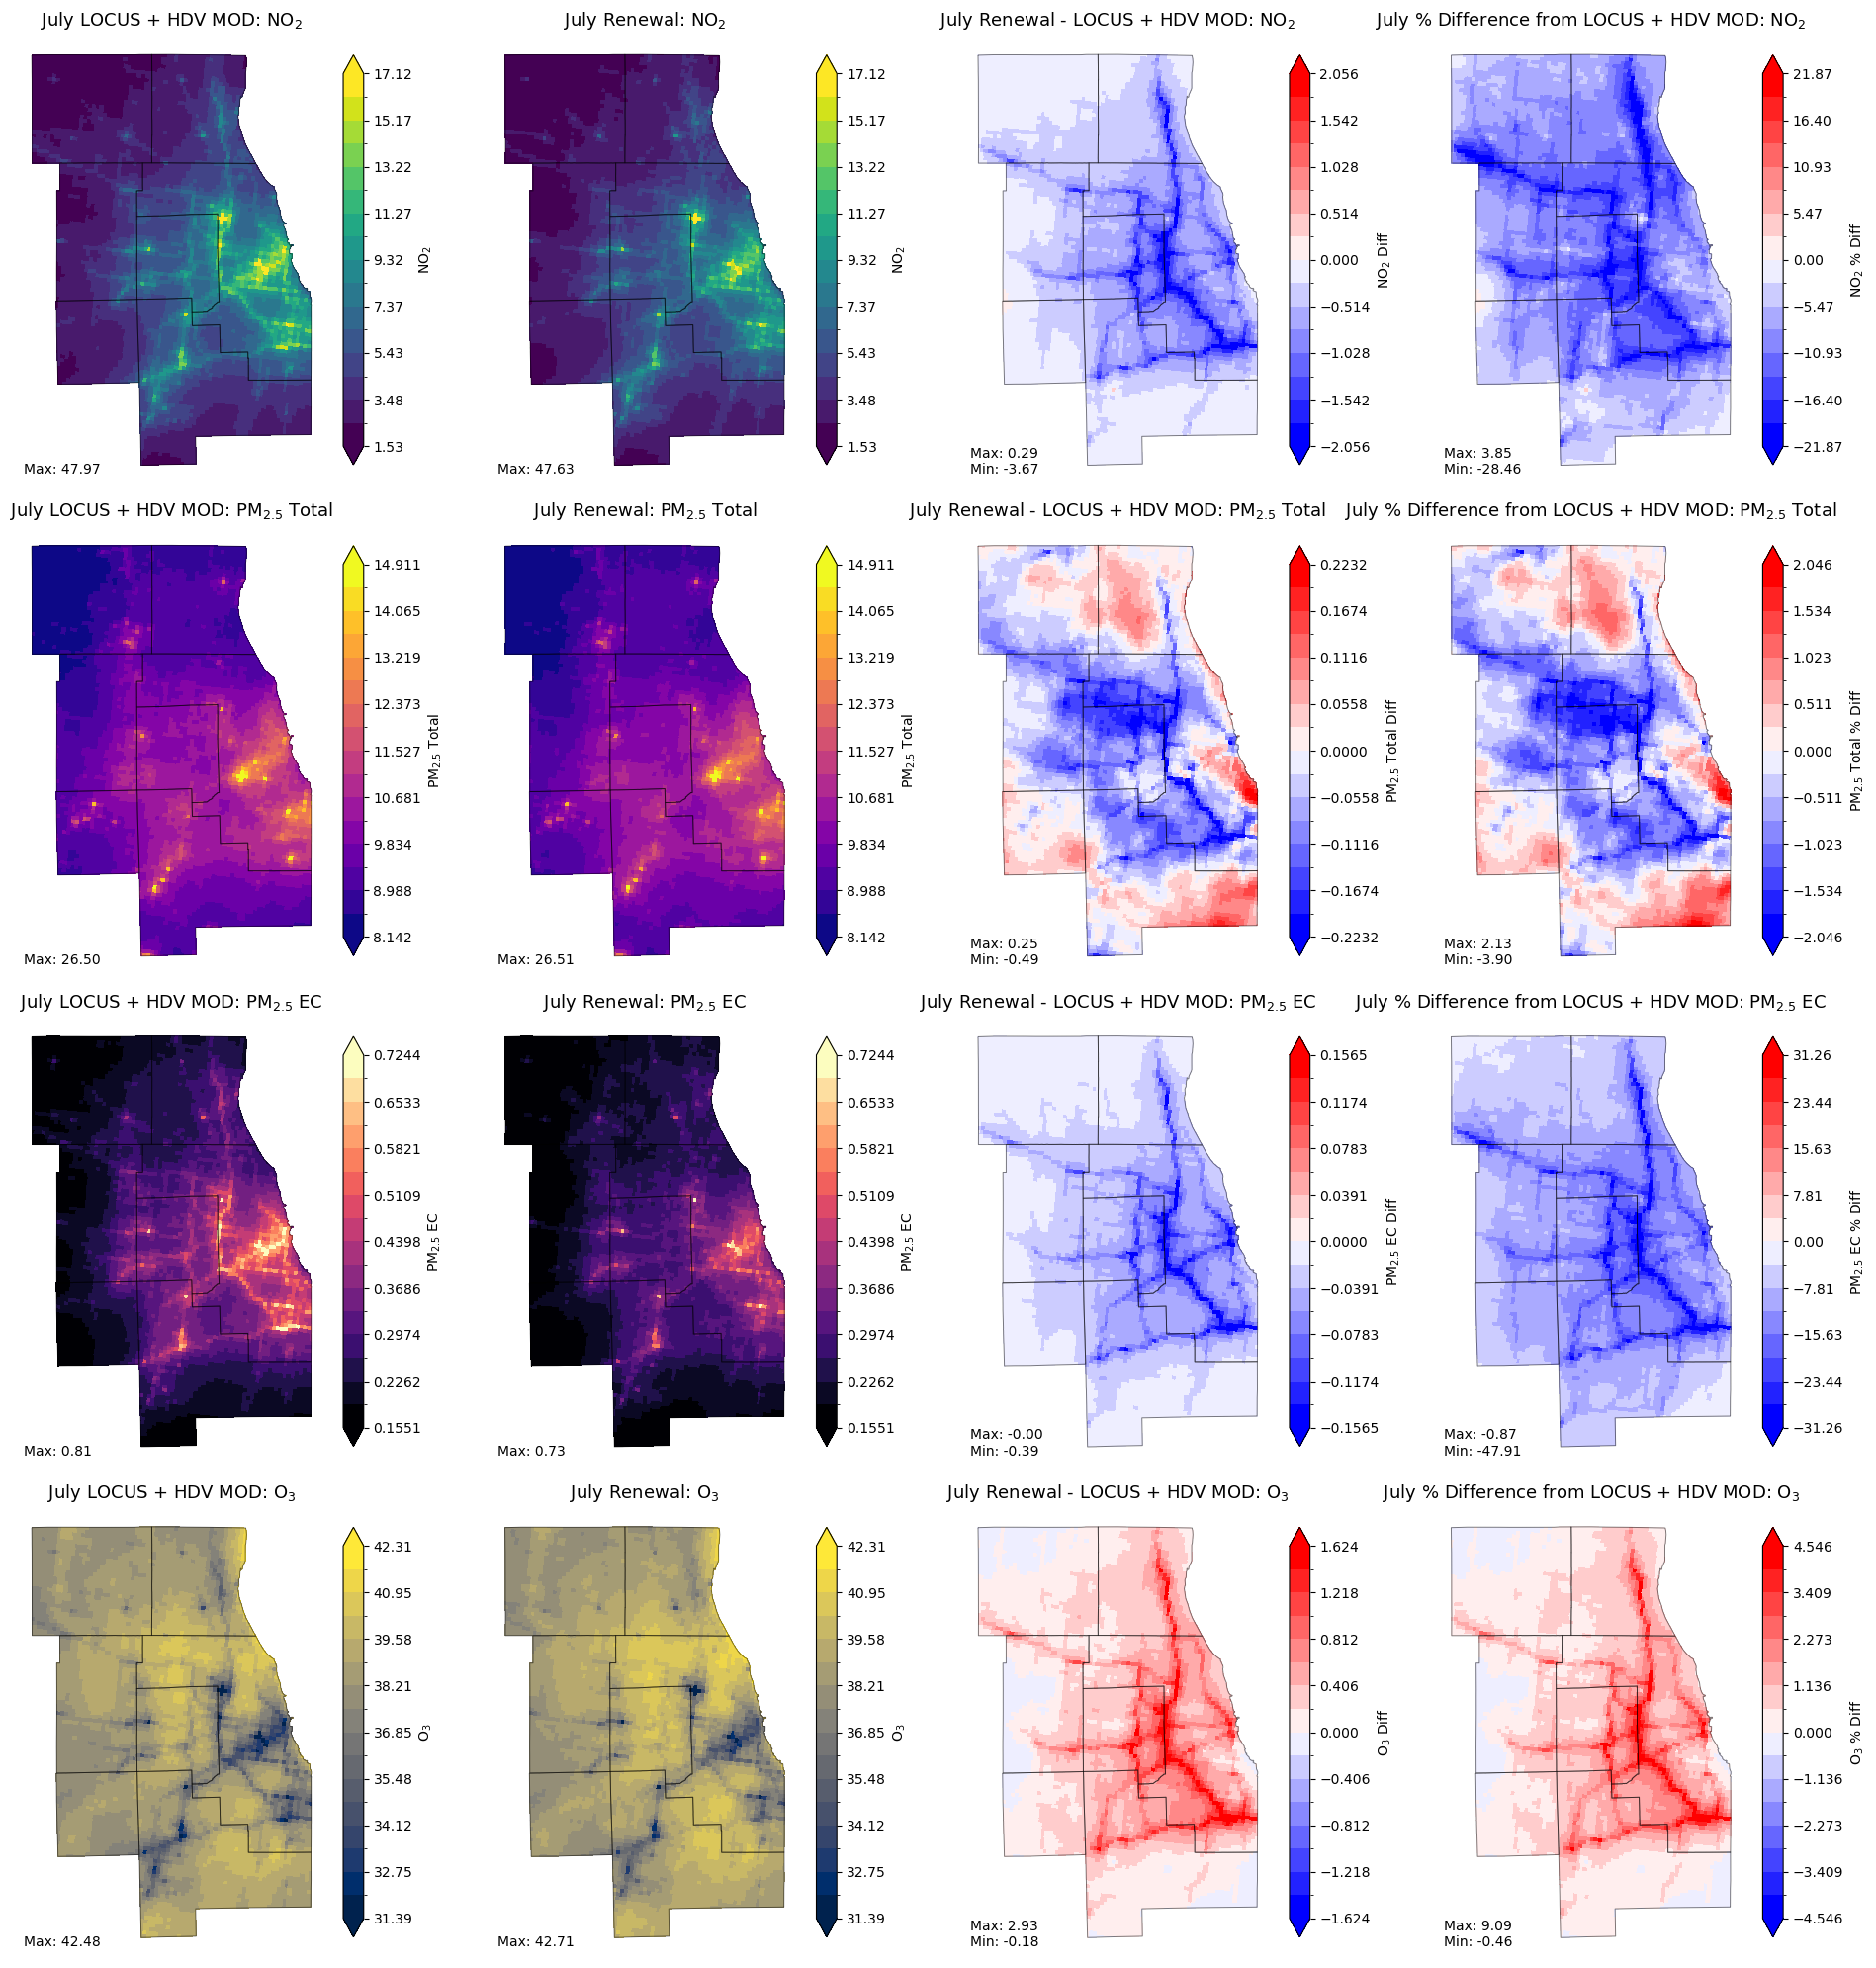

In [20]:
# ---------------------------------------------------
# idling + renewal
# ---------------------------------------------------
abs_styles = {}

for pol in pollutants:
    vals_all = []

    for gdf in [cmap_idling, cmap_renewal]:
        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vals_all.append(vals)

    vals_all = np.concatenate(vals_all)

    vmin = np.quantile(vals_all, 0.001)
    vmax = np.quantile(vals_all, 0.999)

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    cmap_disc = ListedColormap(
        plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))
    )
    bounds = np.linspace(vmin, vmax, N_BINS + 1)
    norm = BoundaryNorm(bounds, cmap_disc.N)

    abs_styles[pol] = {
        "vmin": vmin,
        "vmax": vmax,
        "bounds": bounds,
        "cmap": cmap_disc,
        "norm": norm
    }

# ---------------------------------------------------
# build styles for difference panels
#   col 3 = renewal - idling
#   col 4 = % diff relative to idling
# ---------------------------------------------------
diff_styles = {}

for pol in pollutants:
    idling_vals = cmap_idling[pol].astype(float).to_numpy()
    renewal_vals = cmap_renewal[pol].astype(float).to_numpy()

    diff_vals = renewal_vals - idling_vals
    pct_vals = np.where(idling_vals != 0, (diff_vals / idling_vals) * 100.0, np.nan)

    diff_vals_finite = diff_vals[np.isfinite(diff_vals)]
    pct_vals_finite = pct_vals[np.isfinite(pct_vals)]

    # symmetric bounds so white is centered at zero
    diff_lim = np.quantile(np.abs(diff_vals_finite), 0.99)
    pct_lim = np.quantile(np.abs(pct_vals_finite), 0.99)

    if np.isclose(diff_lim, 0):
        diff_lim = 1e-6
    if np.isclose(pct_lim, 0):
        pct_lim = 1e-6

    diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
    pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)

    diff_cmap = ListedColormap(
        plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
    )
    pct_cmap = ListedColormap(
        plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
    )

    diff_norm = BoundaryNorm(diff_bounds, diff_cmap.N)
    pct_norm = BoundaryNorm(pct_bounds, pct_cmap.N)

    diff_styles[pol] = {
        "diff_bounds": diff_bounds,
        "diff_cmap": diff_cmap,
        "diff_norm": diff_norm,
        "pct_bounds": pct_bounds,
        "pct_cmap": pct_cmap,
        "pct_norm": pct_norm,
    }

# ---------------------------------------------------
# make plotting GeoDataFrames
# ---------------------------------------------------
plot_idling = cmap_idling.copy()
plot_renewal = cmap_renewal.copy()
plot_diff = cmap_renewal.copy()
plot_pct = cmap_renewal.copy()

for pol in pollutants:
    plot_diff[pol] = cmap_renewal[pol].astype(float) - cmap_idling[pol].astype(float)
    plot_pct[pol] = np.where(
        cmap_idling[pol].astype(float) != 0,
        ((cmap_renewal[pol].astype(float) - cmap_idling[pol].astype(float)) / cmap_idling[pol].astype(float)) * 100.0,
        np.nan
    )

scenario_gdfs = {
    "LOCUS + HDV MOD": plot_idling,
    "Renewal": plot_renewal,
    "Renewal - LOCUS + HDV MOD": plot_diff,
    "% Difference from LOCUS + HDV MOD": plot_pct,
}

scenario_names = [
    "LOCUS + HDV MOD",
    "Renewal",
    "Renewal - LOCUS + HDV MOD",
    "% Difference from LOCUS + HDV MOD"
]

# ---------------------------------------------------
# plot
# ---------------------------------------------------
fig, axs = plt.subplots(
    nrows=len(pollutants),
    ncols=4,
    figsize=(20, 20),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for i, pol in enumerate(pollutants):
    for j, scen in enumerate(scenario_names):
        ax = axs[i, j]
        gdf = scenario_gdfs[scen]

        # choose style by column
        if j in [0, 1]:
            style = abs_styles[pol]
            cmap_disc = style["cmap"]
            norm = style["norm"]
            bounds = style["bounds"]
            extend_opt = "both"
        elif j == 2:
            style = diff_styles[pol]
            cmap_disc = style["diff_cmap"]
            norm = style["diff_norm"]
            bounds = style["diff_bounds"]
            extend_opt = "both"
        else:
            style = diff_styles[pol]
            cmap_disc = style["pct_cmap"]
            norm = style["pct_norm"]
            bounds = style["pct_bounds"]
            extend_opt = "both"

        gdf.plot(
            column=pol,
            ax=ax,
            cmap=cmap_disc,
            norm=norm,
            edgecolor="none",
            antialiased=False
        )

        cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)
        # domain_tracts.boundary.plot(ax=ax, color="k", alpha=0.15, linewidth=0.2)

        ax.set_title(f"July {scen}: {plot_config[pol]['title']}", fontsize=13)
        ax.set_axis_off()

        # panel colorbar
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
        sm._A = []
        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            boundaries=bounds,
            ticks=bounds[::2],
            spacing="proportional",
            extend=extend_opt
        )

        if j == 3:
            cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=10)
        elif j == 2:
            cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=10)
        else:
            cbar.set_label(plot_config[pol]["label"], fontsize=10)

        # annotations
        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]

        vmax_panel = float(np.nanmax(vals))
        vmin_panel = float(np.nanmin(vals))

        if j in [0, 1]:
            annot_text = f"Max: {vmax_panel:.2f}"
        else:
            annot_text = f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"

        ax.text(
            0.02, 0.02,
            annot_text,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            color="black",
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                boxstyle="round,pad=0.25",
                linewidth=0
            )
        )

plt.tight_layout()
plt.show()

C:\Users\x12la\AppData\Local\Temp\ipykernel_5368\2287242382.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_5368\2287242382.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_5368\2287242382.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` i

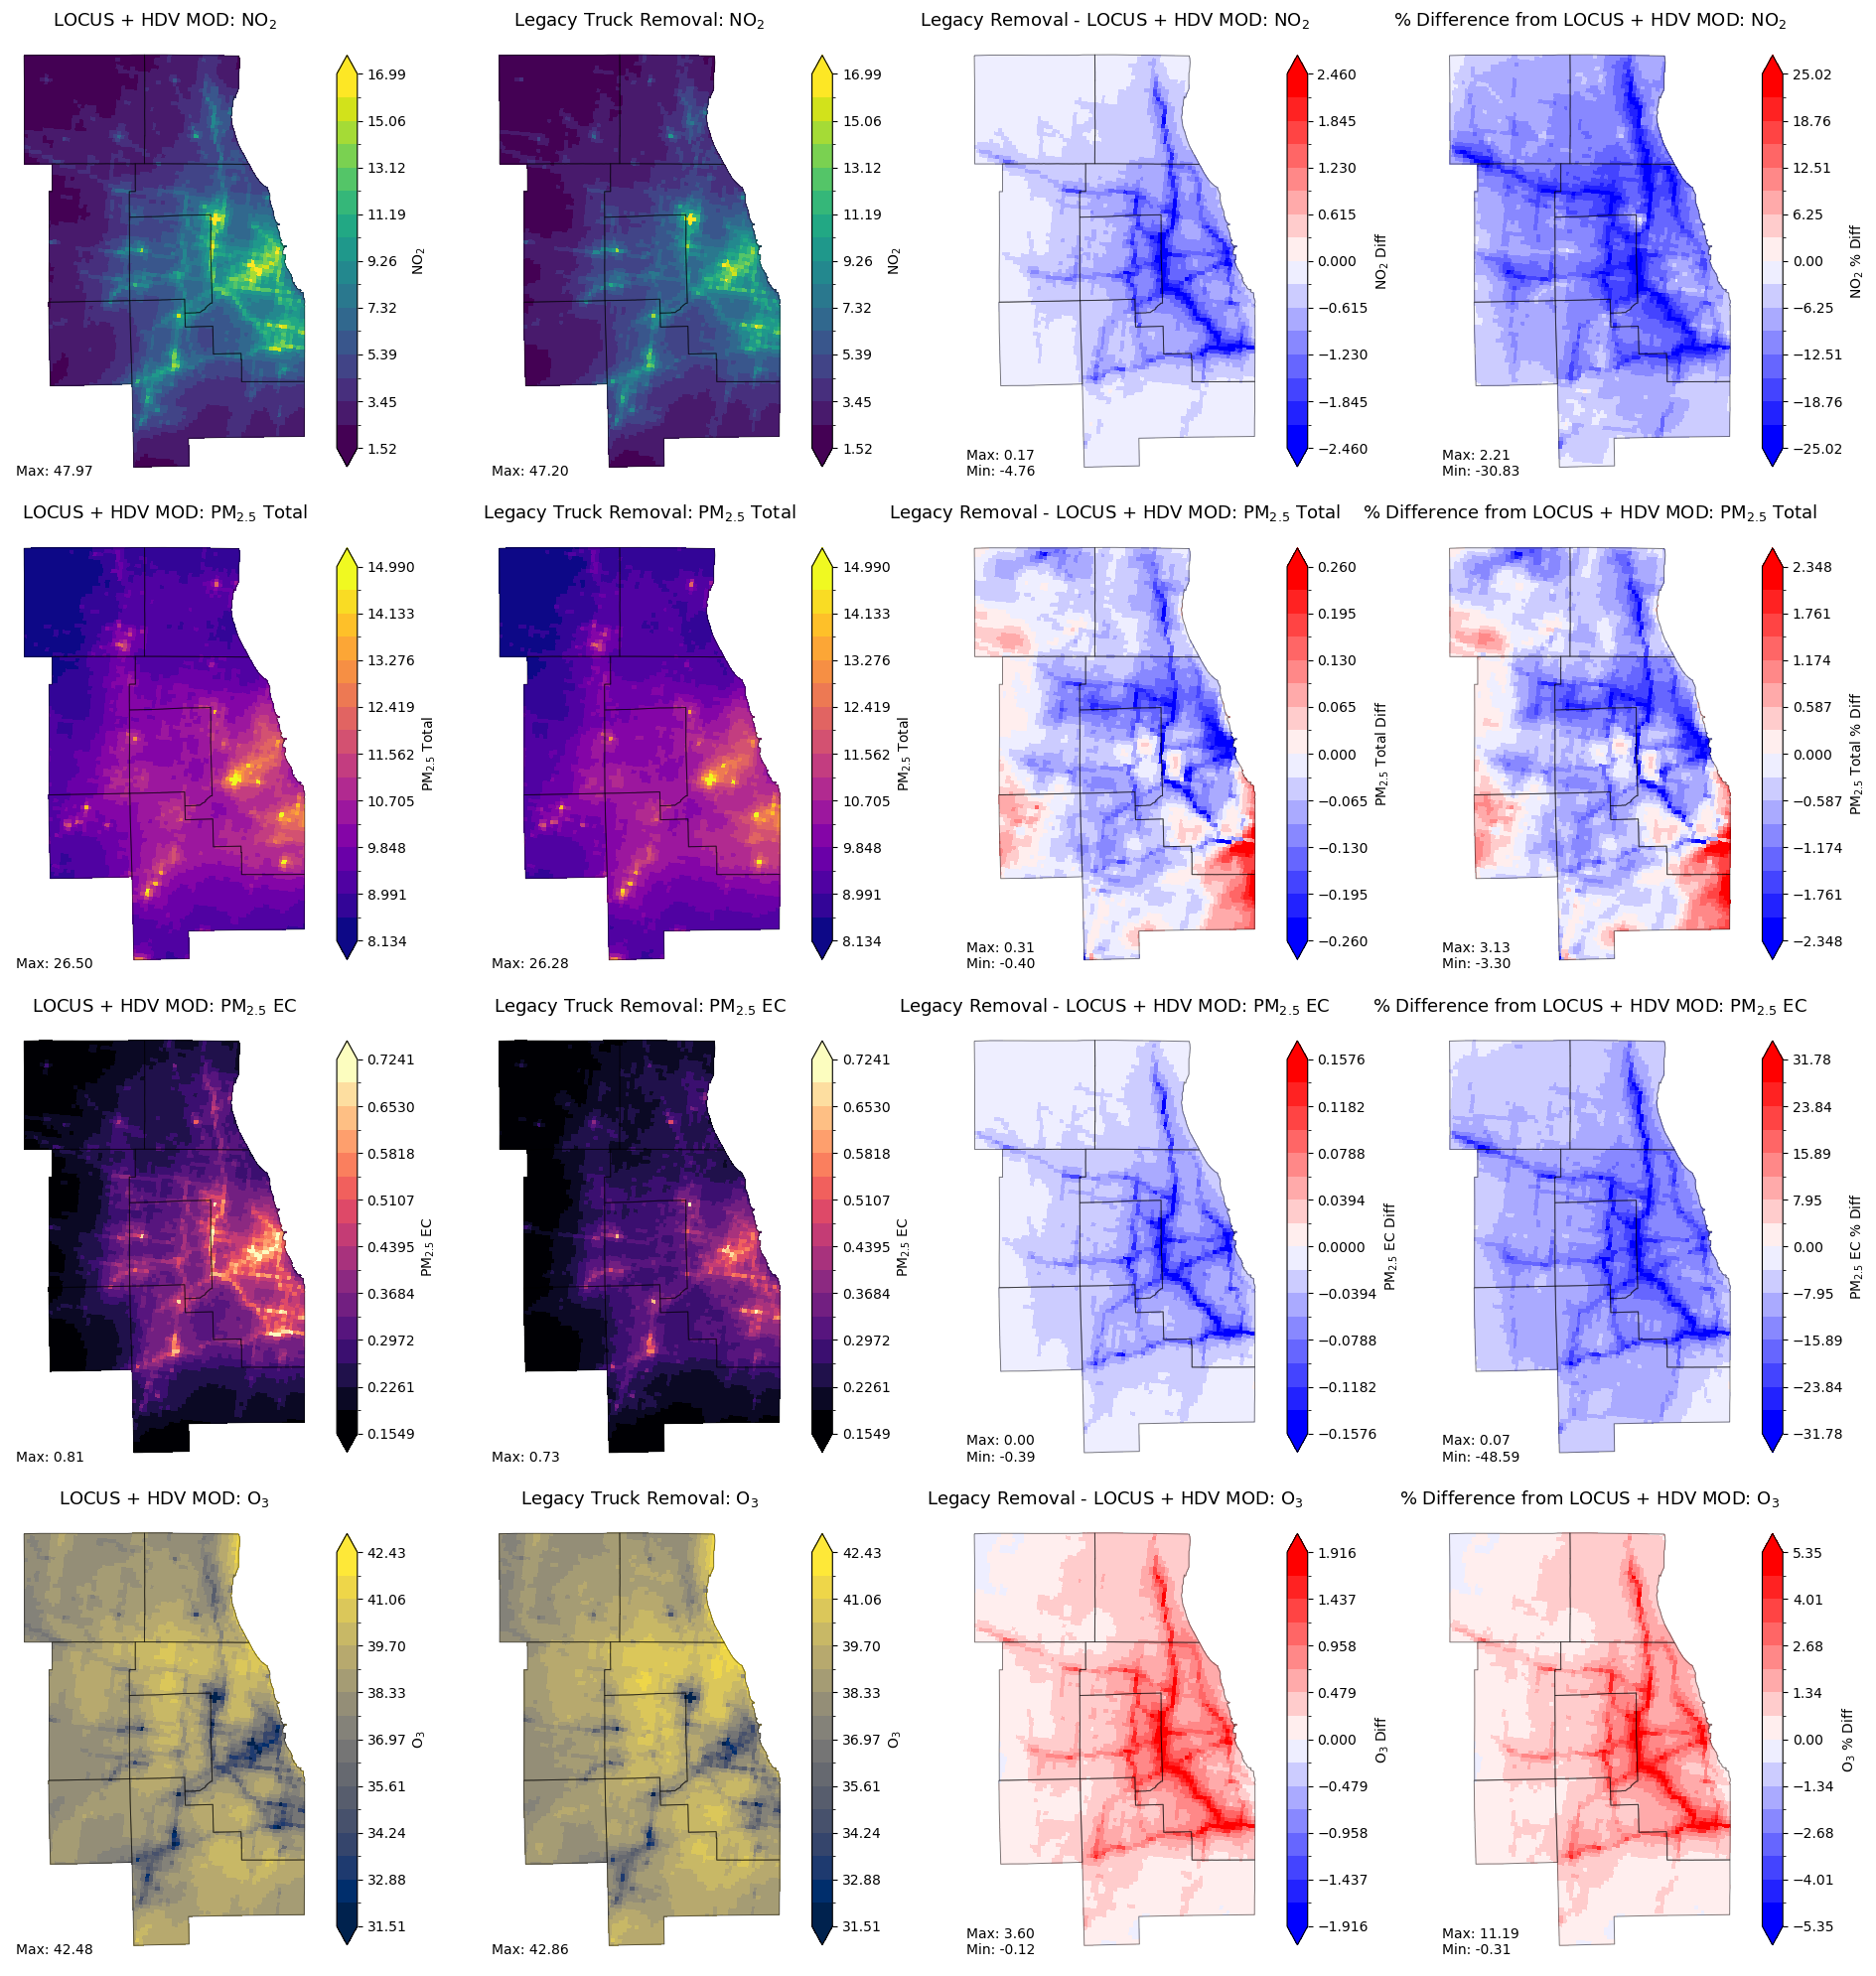

In [29]:
# ---------------------------------------------------
# idling + zero pre2010
# ---------------------------------------------------
abs_styles = {}

for pol in pollutants:
    vals_all = []

    for gdf in [cmap_idling, cmap_zeropre2010s]:
        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vals_all.append(vals)

    vals_all = np.concatenate(vals_all)

    vmin = np.quantile(vals_all, 0.001)
    vmax = np.quantile(vals_all, 0.999)

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    cmap_disc = ListedColormap(
        plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))
    )
    bounds = np.linspace(vmin, vmax, N_BINS + 1)
    norm = BoundaryNorm(bounds, cmap_disc.N)

    abs_styles[pol] = {
        "bounds": bounds,
        "cmap": cmap_disc,
        "norm": norm
    }

# ---------------------------------------------------
# build styles for difference panels
# ---------------------------------------------------
diff_styles = {}

for pol in pollutants:
    idling_vals = cmap_idling[pol].astype(float).to_numpy()
    zero_vals = cmap_zeropre2010s[pol].astype(float).to_numpy()

    diff_vals = zero_vals - idling_vals
    pct_vals = np.where(idling_vals != 0, (diff_vals / idling_vals) * 100.0, np.nan)

    diff_vals = diff_vals[np.isfinite(diff_vals)]
    pct_vals = pct_vals[np.isfinite(pct_vals)]

    diff_lim = np.quantile(np.abs(diff_vals), 0.99)
    pct_lim = np.quantile(np.abs(pct_vals), 0.99)

    if np.isclose(diff_lim, 0):
        diff_lim = 1e-6
    if np.isclose(pct_lim, 0):
        pct_lim = 1e-6

    diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
    pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)

    diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
    pct_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))

    diff_styles[pol] = {
        "diff_bounds": diff_bounds,
        "diff_cmap": diff_cmap,
        "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N),
        "pct_bounds": pct_bounds,
        "pct_cmap": pct_cmap,
        "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N),
    }

# ---------------------------------------------------
# make plotting GeoDataFrames
# ---------------------------------------------------
plot_idling = cmap_idling.copy()
plot_zero = cmap_zeropre2010s.copy()
plot_diff = cmap_zeropre2010s.copy()
plot_pct = cmap_zeropre2010s.copy()

for pol in pollutants:
    plot_diff[pol] = cmap_zeropre2010s[pol].astype(float) - cmap_idling[pol].astype(float)
    plot_pct[pol] = np.where(
        cmap_idling[pol].astype(float) != 0,
        ((cmap_zeropre2010s[pol].astype(float) - cmap_idling[pol].astype(float)) /
         cmap_idling[pol].astype(float)) * 100.0,
        np.nan
    )

scenario_gdfs = {
    "LOCUS + HDV MOD": plot_idling,
    "Legacy Truck Removal": plot_zero,
    "Legacy Removal - LOCUS + HDV MOD": plot_diff,
    "% Difference from LOCUS + HDV MOD": plot_pct,
}

scenario_names = list(scenario_gdfs.keys())

# ---------------------------------------------------
# plot
# ---------------------------------------------------
fig, axs = plt.subplots(
    nrows=len(pollutants),
    ncols=4,
    figsize=(20, 20),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for i, pol in enumerate(pollutants):
    for j, scen in enumerate(scenario_names):
        ax = axs[i, j]
        gdf = scenario_gdfs[scen]

        if j in [0, 1]:
            style = abs_styles[pol]
            cmap_disc = style["cmap"]
            norm = style["norm"]
            bounds = style["bounds"]
        elif j == 2:
            style = diff_styles[pol]
            cmap_disc = style["diff_cmap"]
            norm = style["diff_norm"]
            bounds = style["diff_bounds"]
        else:
            style = diff_styles[pol]
            cmap_disc = style["pct_cmap"]
            norm = style["pct_norm"]
            bounds = style["pct_bounds"]

        gdf.plot(
            column=pol,
            ax=ax,
            cmap=cmap_disc,
            norm=norm,
            edgecolor="none",
            antialiased=False
        )

        cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)

        ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=13)
        ax.set_axis_off()

        # colorbar
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
        sm._A = []
        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            boundaries=bounds,
            ticks=bounds[::2],
            spacing="proportional",
            extend='both'
        )

        if j == 3:
            cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=10)
        elif j == 2:
            cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=10)
        else:
            cbar.set_label(plot_config[pol]["label"], fontsize=10)

        # annotations
        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]

        vmax_panel = float(np.nanmax(vals))
        vmin_panel = float(np.nanmin(vals))

        if j in [0, 1]:
            txt = f"Max: {vmax_panel:.2f}"
        else:
            txt = f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"

        ax.text(
            0.02, 0.02,
            txt,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.25", linewidth=0)
        )

plt.tight_layout()
plt.show()

C:\Users\x12la\AppData\Local\Temp\ipykernel_5368\3966874233.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_5368\3966874233.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_5368\3966874233.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` i

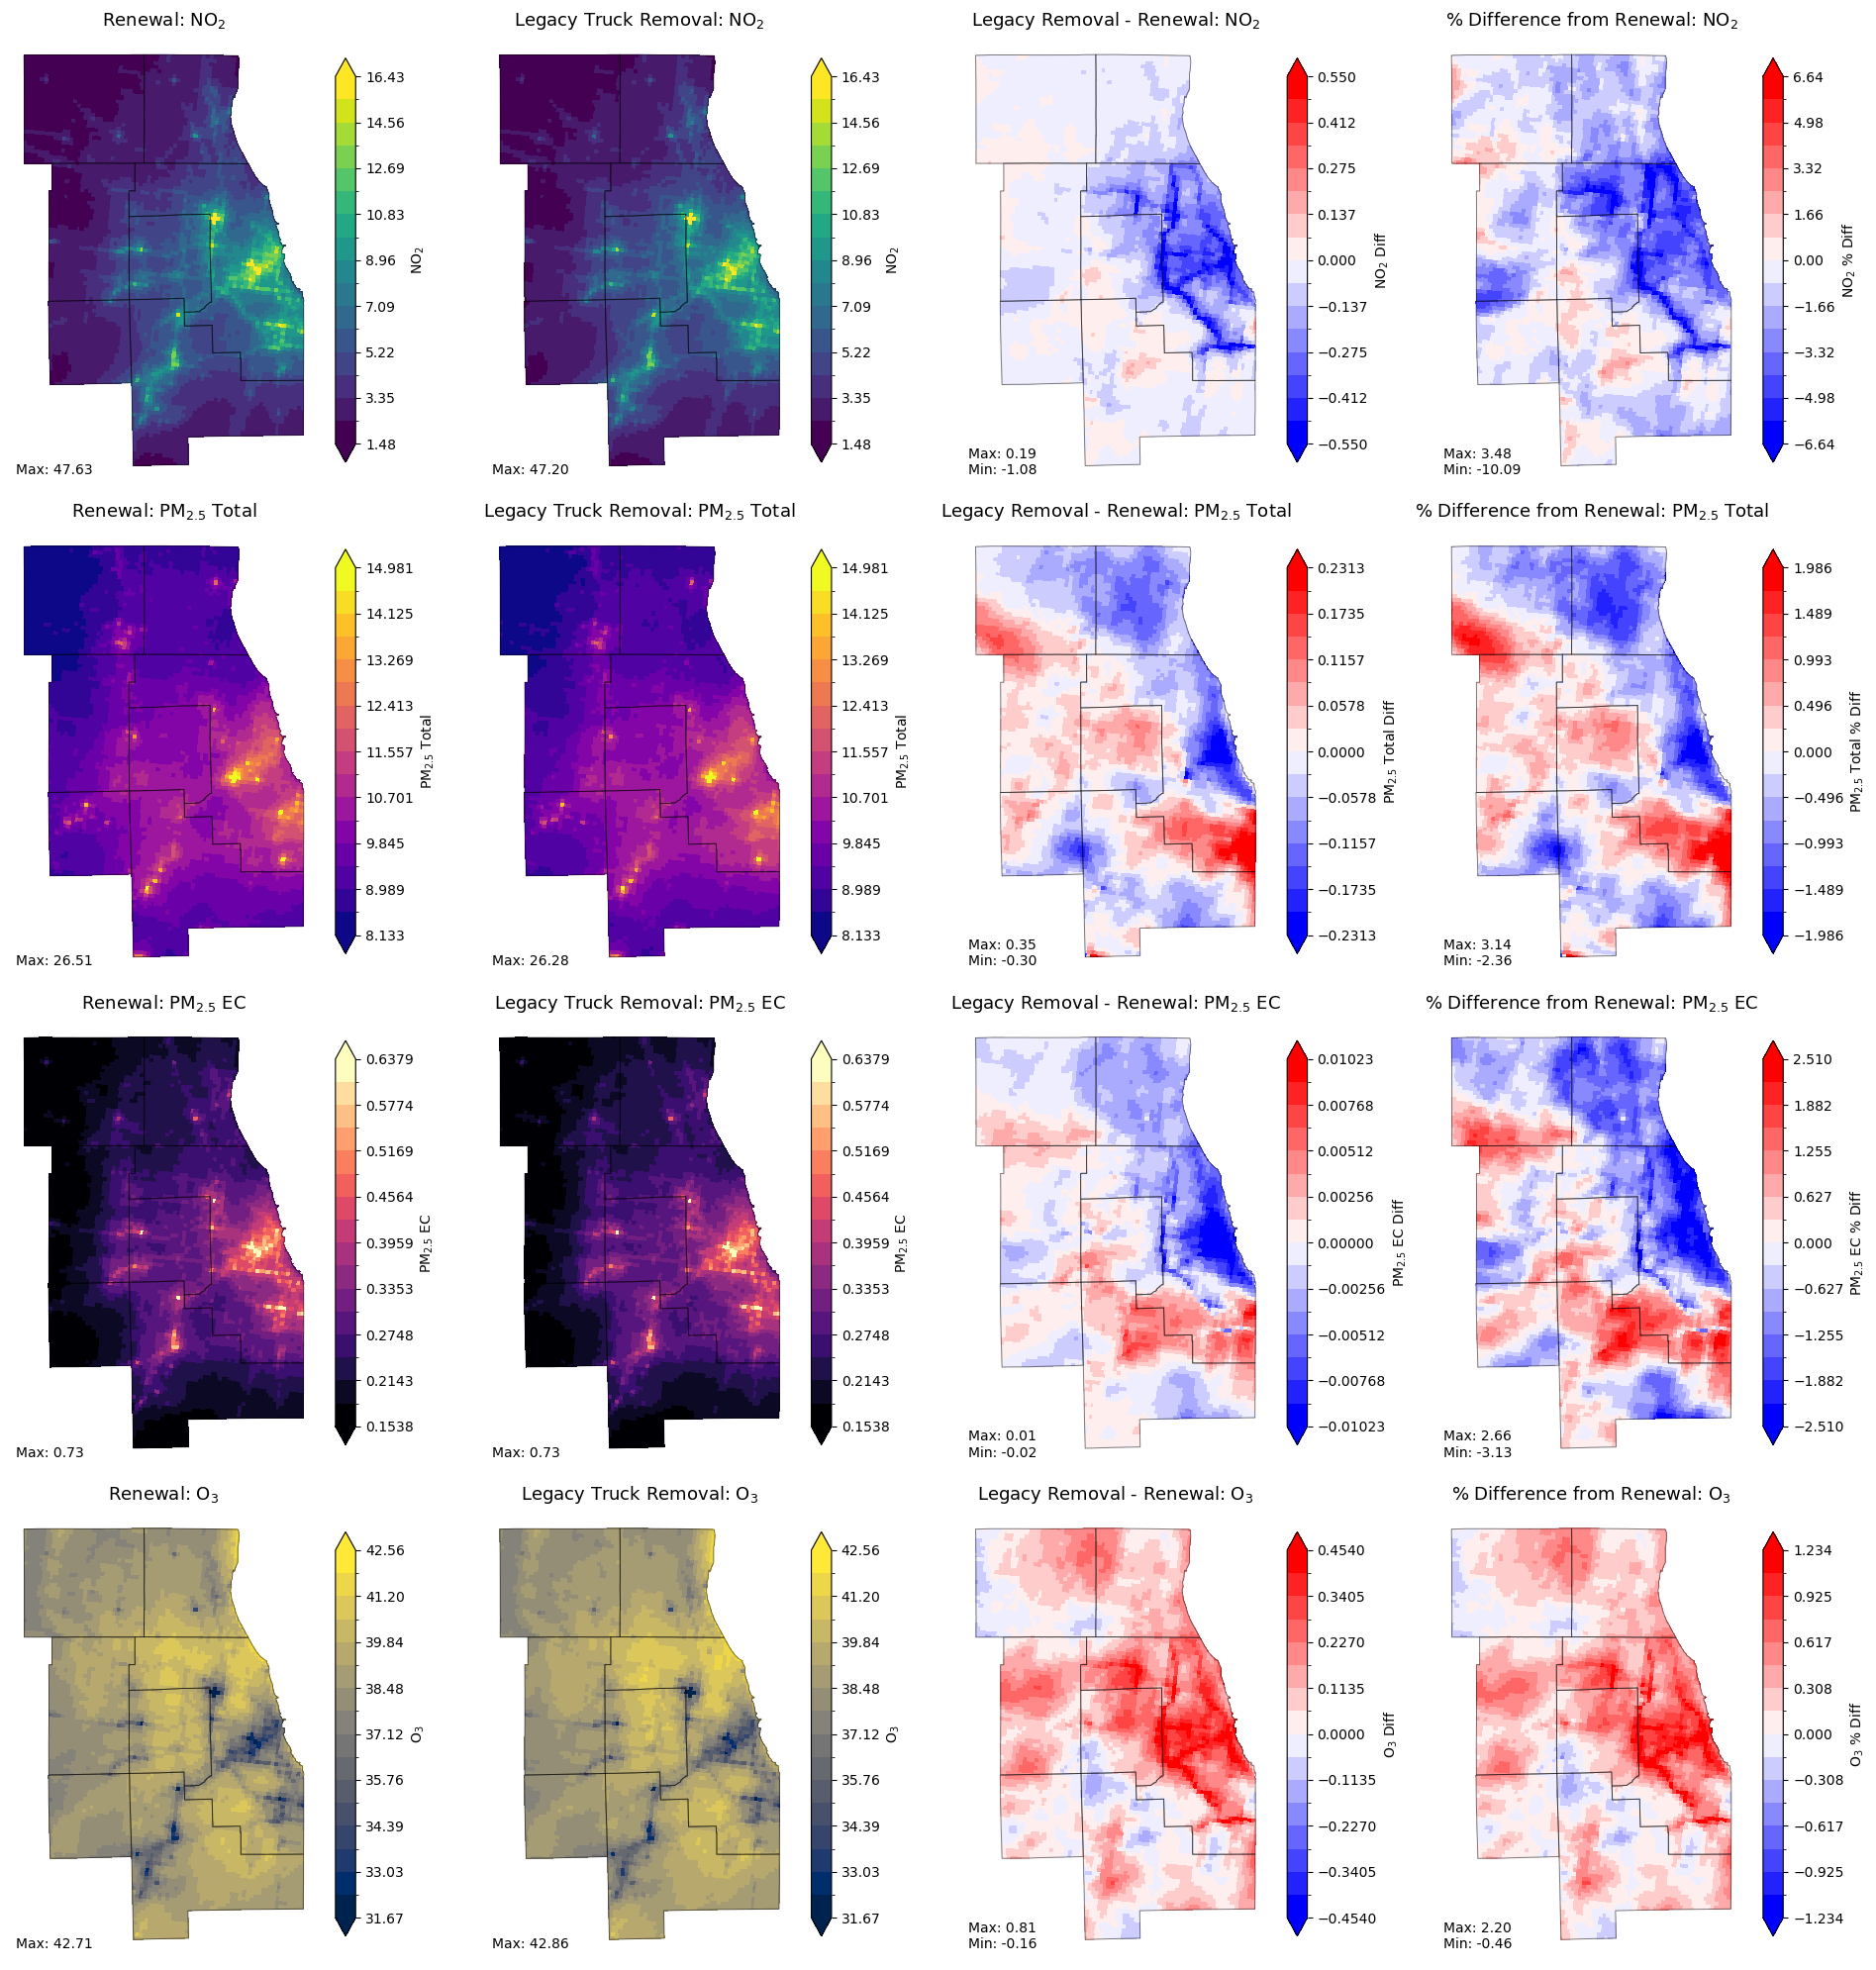

In [30]:
# ---------------------------------------------------
# renewal + zero pre2010
# ---------------------------------------------------
abs_styles = {}

for pol in pollutants:
    vals_all = []

    for gdf in [cmap_renewal, cmap_zeropre2010s]:
        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vals_all.append(vals)

    vals_all = np.concatenate(vals_all)

    vmin = np.quantile(vals_all, 0.001)
    vmax = np.quantile(vals_all, 0.999)

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    cmap_disc = ListedColormap(
        plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))
    )
    bounds = np.linspace(vmin, vmax, N_BINS + 1)
    norm = BoundaryNorm(bounds, cmap_disc.N)

    abs_styles[pol] = {
        "bounds": bounds,
        "cmap": cmap_disc,
        "norm": norm
    }

# ---------------------------------------------------
# build styles for difference panels
#   col 3 = zero pre2010 - renewal
#   col 4 = % diff relative to renewal
# ---------------------------------------------------
diff_styles = {}

for pol in pollutants:
    renewal_vals = cmap_renewal[pol].astype(float).to_numpy()
    zero_vals = cmap_zeropre2010s[pol].astype(float).to_numpy()

    diff_vals = zero_vals - renewal_vals
    pct_vals = np.where(renewal_vals != 0, (diff_vals / renewal_vals) * 100.0, np.nan)

    diff_vals = diff_vals[np.isfinite(diff_vals)]
    pct_vals = pct_vals[np.isfinite(pct_vals)]

    diff_lim = np.quantile(np.abs(diff_vals), 0.99)
    pct_lim = np.quantile(np.abs(pct_vals), 0.99)

    if np.isclose(diff_lim, 0):
        diff_lim = 1e-6
    if np.isclose(pct_lim, 0):
        pct_lim = 1e-6

    diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
    pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)

    diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
    pct_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))

    diff_styles[pol] = {
        "diff_bounds": diff_bounds,
        "diff_cmap": diff_cmap,
        "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N),
        "pct_bounds": pct_bounds,
        "pct_cmap": pct_cmap,
        "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N),
    }

# ---------------------------------------------------
# make plotting GeoDataFrames
# ---------------------------------------------------
plot_renewal = cmap_renewal.copy()
plot_zero = cmap_zeropre2010s.copy()
plot_diff = cmap_zeropre2010s.copy()
plot_pct = cmap_zeropre2010s.copy()

for pol in pollutants:
    plot_diff[pol] = cmap_zeropre2010s[pol].astype(float) - cmap_renewal[pol].astype(float)
    plot_pct[pol] = np.where(
        cmap_renewal[pol].astype(float) != 0,
        ((cmap_zeropre2010s[pol].astype(float) - cmap_renewal[pol].astype(float)) /
         cmap_renewal[pol].astype(float)) * 100.0,
        np.nan
    )

scenario_gdfs = {
    "Renewal": plot_renewal,
    "Legacy Truck Removal": plot_zero,
    "Legacy Removal - Renewal": plot_diff,
    "% Difference from Renewal": plot_pct,
}

scenario_names = list(scenario_gdfs.keys())

# ---------------------------------------------------
# plot
# ---------------------------------------------------
fig, axs = plt.subplots(
    nrows=len(pollutants),
    ncols=4,
    figsize=(20, 20),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for i, pol in enumerate(pollutants):
    for j, scen in enumerate(scenario_names):
        ax = axs[i, j]
        gdf = scenario_gdfs[scen]

        if j in [0, 1]:
            style = abs_styles[pol]
            cmap_disc = style["cmap"]
            norm = style["norm"]
            bounds = style["bounds"]
        elif j == 2:
            style = diff_styles[pol]
            cmap_disc = style["diff_cmap"]
            norm = style["diff_norm"]
            bounds = style["diff_bounds"]
        else:
            style = diff_styles[pol]
            cmap_disc = style["pct_cmap"]
            norm = style["pct_norm"]
            bounds = style["pct_bounds"]

        gdf.plot(
            column=pol,
            ax=ax,
            cmap=cmap_disc,
            norm=norm,
            edgecolor="none",
            antialiased=False
        )

        cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)

        ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=13)
        ax.set_axis_off()

        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
        sm._A = []
        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            boundaries=bounds,
            ticks=bounds[::2],
            spacing="proportional",
            extend='both'
        )

        if j == 3:
            cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=10)
        elif j == 2:
            cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=10)
        else:
            cbar.set_label(plot_config[pol]["label"], fontsize=10)

        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]

        vmax_panel = float(np.nanmax(vals))
        vmin_panel = float(np.nanmin(vals))

        if j in [0, 1]:
            txt = f"Max: {vmax_panel:.2f}"
        else:
            txt = f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"

        ax.text(
            0.02, 0.02,
            txt,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.25", linewidth=0)
        )

plt.tight_layout()
plt.show()

C:\Users\x12la\AppData\Local\Temp\ipykernel_5368\1353000225.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_5368\1353000225.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_5368\1353000225.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` i

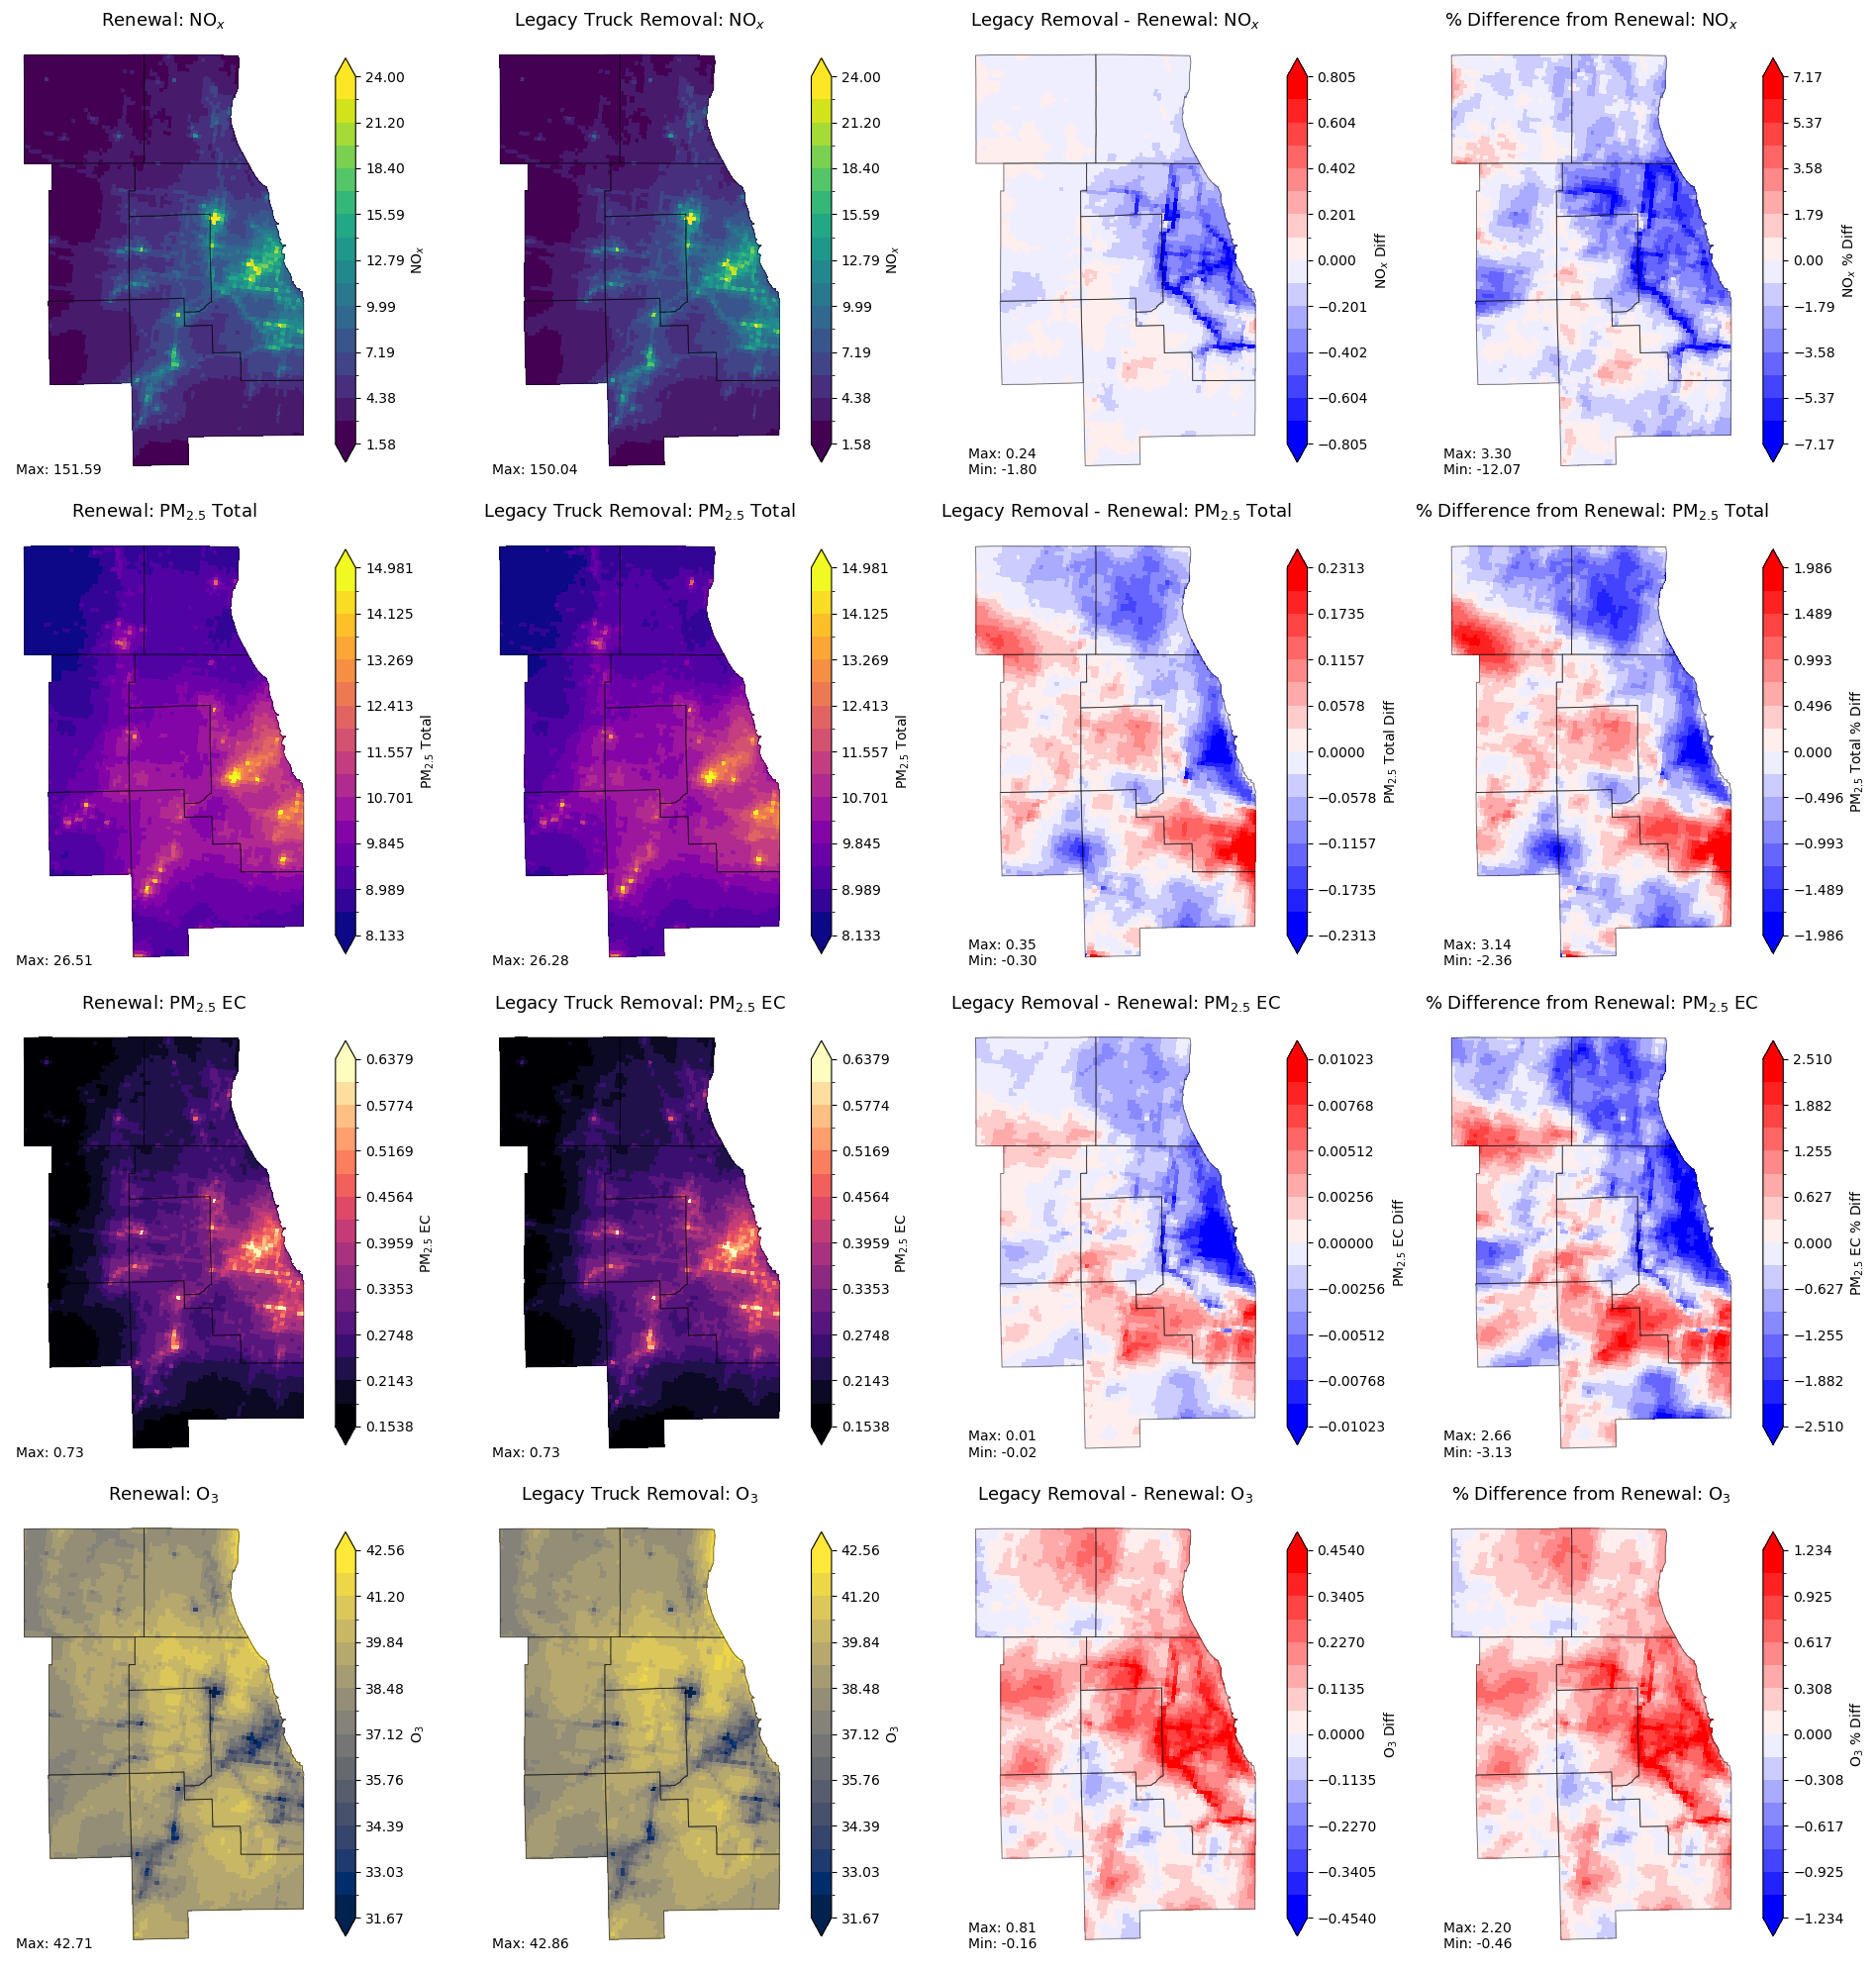

In [31]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs

N_BINS = 16

# pollutant plotting setup
plot_config = {
    "NOX": {
        "cmap_name": "viridis",
        "title": "NO$_x$",
        "label": "NO$_x$",
    },
    "PM25_TOT": {
        "cmap_name": "plasma",
        "title": "PM$_{2.5}$ Total",
        "label": "PM$_{2.5}$ Total",
    },
    "PM25_EC": {
        "cmap_name": "magma",
        "title": "PM$_{2.5}$ EC",
        "label": "PM$_{2.5}$ EC",
    },
    "O3": {
        "cmap_name": "cividis",
        "title": "O$_3$",
        "label": "O$_3$",
    },
}

pollutants = ["NOX", "PM25_TOT", "PM25_EC", "O3"]

# ---------------------------------------------------
# build styles for absolute panels: renewal + zero pre2010
# ---------------------------------------------------
abs_styles = {}

for pol in pollutants:
    vals_all = []

    for gdf in [cmap_renewal, cmap_zeropre2010s]:
        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vals_all.append(vals)

    vals_all = np.concatenate(vals_all)

    vmin = np.quantile(vals_all, 0.001)
    vmax = np.quantile(vals_all, 0.999)

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    cmap_disc = ListedColormap(
        plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))
    )
    bounds = np.linspace(vmin, vmax, N_BINS + 1)
    norm = BoundaryNorm(bounds, cmap_disc.N)

    abs_styles[pol] = {
        "bounds": bounds,
        "cmap": cmap_disc,
        "norm": norm
    }

# ---------------------------------------------------
# build styles for difference panels
#   col 3 = zero pre2010 - renewal
#   col 4 = % diff relative to renewal
# ---------------------------------------------------
diff_styles = {}

for pol in pollutants:
    renewal_vals = cmap_renewal[pol].astype(float).to_numpy()
    zero_vals = cmap_zeropre2010s[pol].astype(float).to_numpy()

    diff_vals = zero_vals - renewal_vals
    pct_vals = np.where(renewal_vals != 0, (diff_vals / renewal_vals) * 100.0, np.nan)

    diff_vals = diff_vals[np.isfinite(diff_vals)]
    pct_vals = pct_vals[np.isfinite(pct_vals)]

    diff_lim = np.quantile(np.abs(diff_vals), 0.99)
    pct_lim = np.quantile(np.abs(pct_vals), 0.99)

    if np.isclose(diff_lim, 0):
        diff_lim = 1e-6
    if np.isclose(pct_lim, 0):
        pct_lim = 1e-6

    diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
    pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)

    diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
    pct_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))

    diff_styles[pol] = {
        "diff_bounds": diff_bounds,
        "diff_cmap": diff_cmap,
        "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N),
        "pct_bounds": pct_bounds,
        "pct_cmap": pct_cmap,
        "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N),
    }

# ---------------------------------------------------
# make plotting GeoDataFrames
# ---------------------------------------------------
plot_renewal = cmap_renewal.copy()
plot_zero = cmap_zeropre2010s.copy()
plot_diff = cmap_zeropre2010s.copy()
plot_pct = cmap_zeropre2010s.copy()

for pol in pollutants:
    plot_diff[pol] = cmap_zeropre2010s[pol].astype(float) - cmap_renewal[pol].astype(float)
    plot_pct[pol] = np.where(
        cmap_renewal[pol].astype(float) != 0,
        ((cmap_zeropre2010s[pol].astype(float) - cmap_renewal[pol].astype(float)) /
         cmap_renewal[pol].astype(float)) * 100.0,
        np.nan
    )

scenario_gdfs = {
    "Renewal": plot_renewal,
    "Legacy Truck Removal": plot_zero,
    "Legacy Removal - Renewal": plot_diff,
    "% Difference from Renewal": plot_pct,
}

scenario_names = list(scenario_gdfs.keys())

# ---------------------------------------------------
# plot
# ---------------------------------------------------
fig, axs = plt.subplots(
    nrows=len(pollutants),
    ncols=4,
    figsize=(20, 20),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for i, pol in enumerate(pollutants):
    for j, scen in enumerate(scenario_names):
        ax = axs[i, j]
        gdf = scenario_gdfs[scen]

        if j in [0, 1]:
            style = abs_styles[pol]
            cmap_disc = style["cmap"]
            norm = style["norm"]
            bounds = style["bounds"]
        elif j == 2:
            style = diff_styles[pol]
            cmap_disc = style["diff_cmap"]
            norm = style["diff_norm"]
            bounds = style["diff_bounds"]
        else:
            style = diff_styles[pol]
            cmap_disc = style["pct_cmap"]
            norm = style["pct_norm"]
            bounds = style["pct_bounds"]

        gdf.plot(
            column=pol,
            ax=ax,
            cmap=cmap_disc,
            norm=norm,
            edgecolor="none",
            antialiased=False
        )

        cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)

        ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=13)
        ax.set_axis_off()

        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
        sm._A = []
        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            boundaries=bounds,
            ticks=bounds[::2],
            spacing="proportional",
            extend='both'
        )

        if j == 3:
            cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=10)
        elif j == 2:
            cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=10)
        else:
            cbar.set_label(plot_config[pol]["label"], fontsize=10)

        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]

        vmax_panel = float(np.nanmax(vals))
        vmin_panel = float(np.nanmin(vals))

        if j in [0, 1]:
            txt = f"Max: {vmax_panel:.2f}"
        else:
            txt = f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"

        ax.text(
            0.02, 0.02,
            txt,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.25", linewidth=0)
        )

plt.tight_layout()
plt.show()

<h1> Primary v Secondary PM2.5 

In [12]:
# ---------------------------------------------------
# based on cb6r3_ae7_aq aerosol species table
# https://github.com/USEPA/CMAQ/blob/main/CCTM/src/MECHS/mechanism_information/cb6r3_ae7_aq/cb6r3_ae7_aq_species_table.md
# ---------------------------------------------------

primary_pm_species = [
    "APOMIJ",   # primary organic matter / primary organic aerosol
    "AECIJ",    # elemental carbon
    "AFEJ",     # iron
    "AALJ",     # aluminum
    "ASIJ",     # silicon
    "ATIJ",     # titanium
    "ACAJ",     # calcium
    "AMGJ",     # magnesium
    "AKJ",      # potassium
    "AMNJ",     # manganese
]

secondary_pm_species = [
    "ASOMIJ",   # secondary organic matter / SOA
    "ASO4IJ",   # sulfate, fine modes
    "ANO3IJ",   # nitrate, fine modes
    "ANH4IJ"    # ammonium, fine modes
]

C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\343064728.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("plasma")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\343064728.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\343064728.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0,

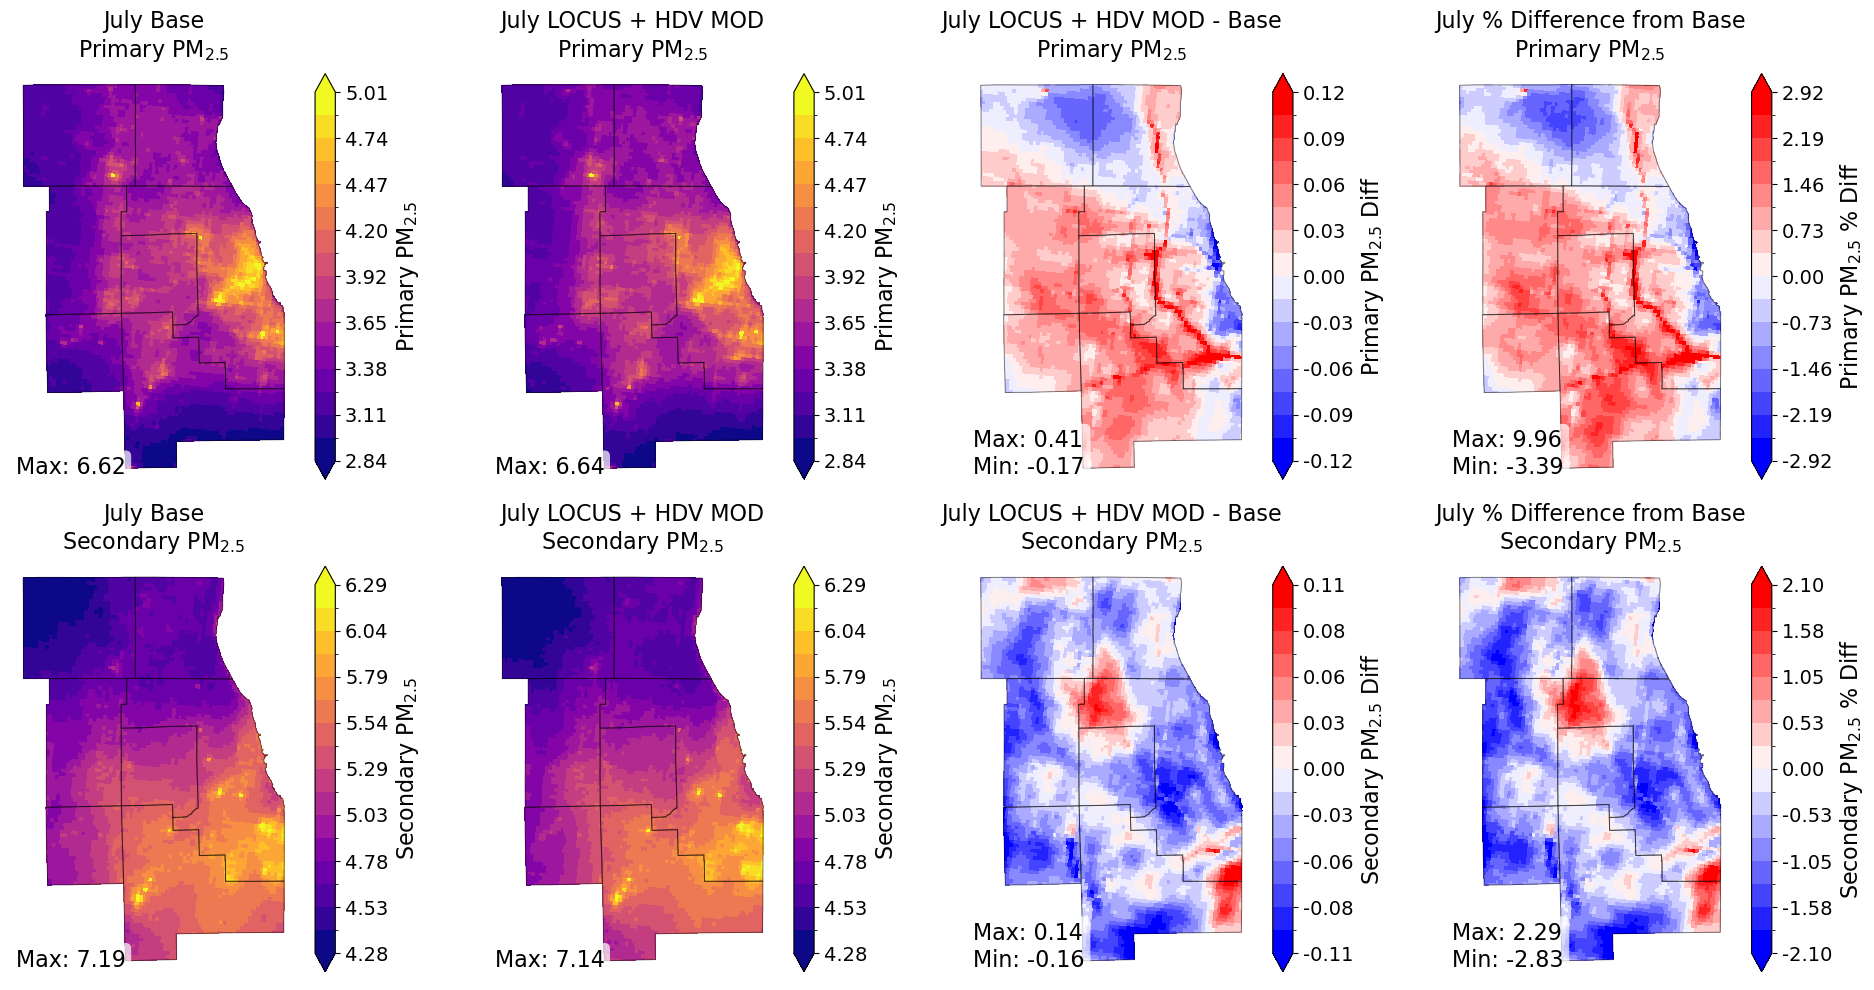

C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\343064728.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("plasma")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\343064728.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\343064728.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0,

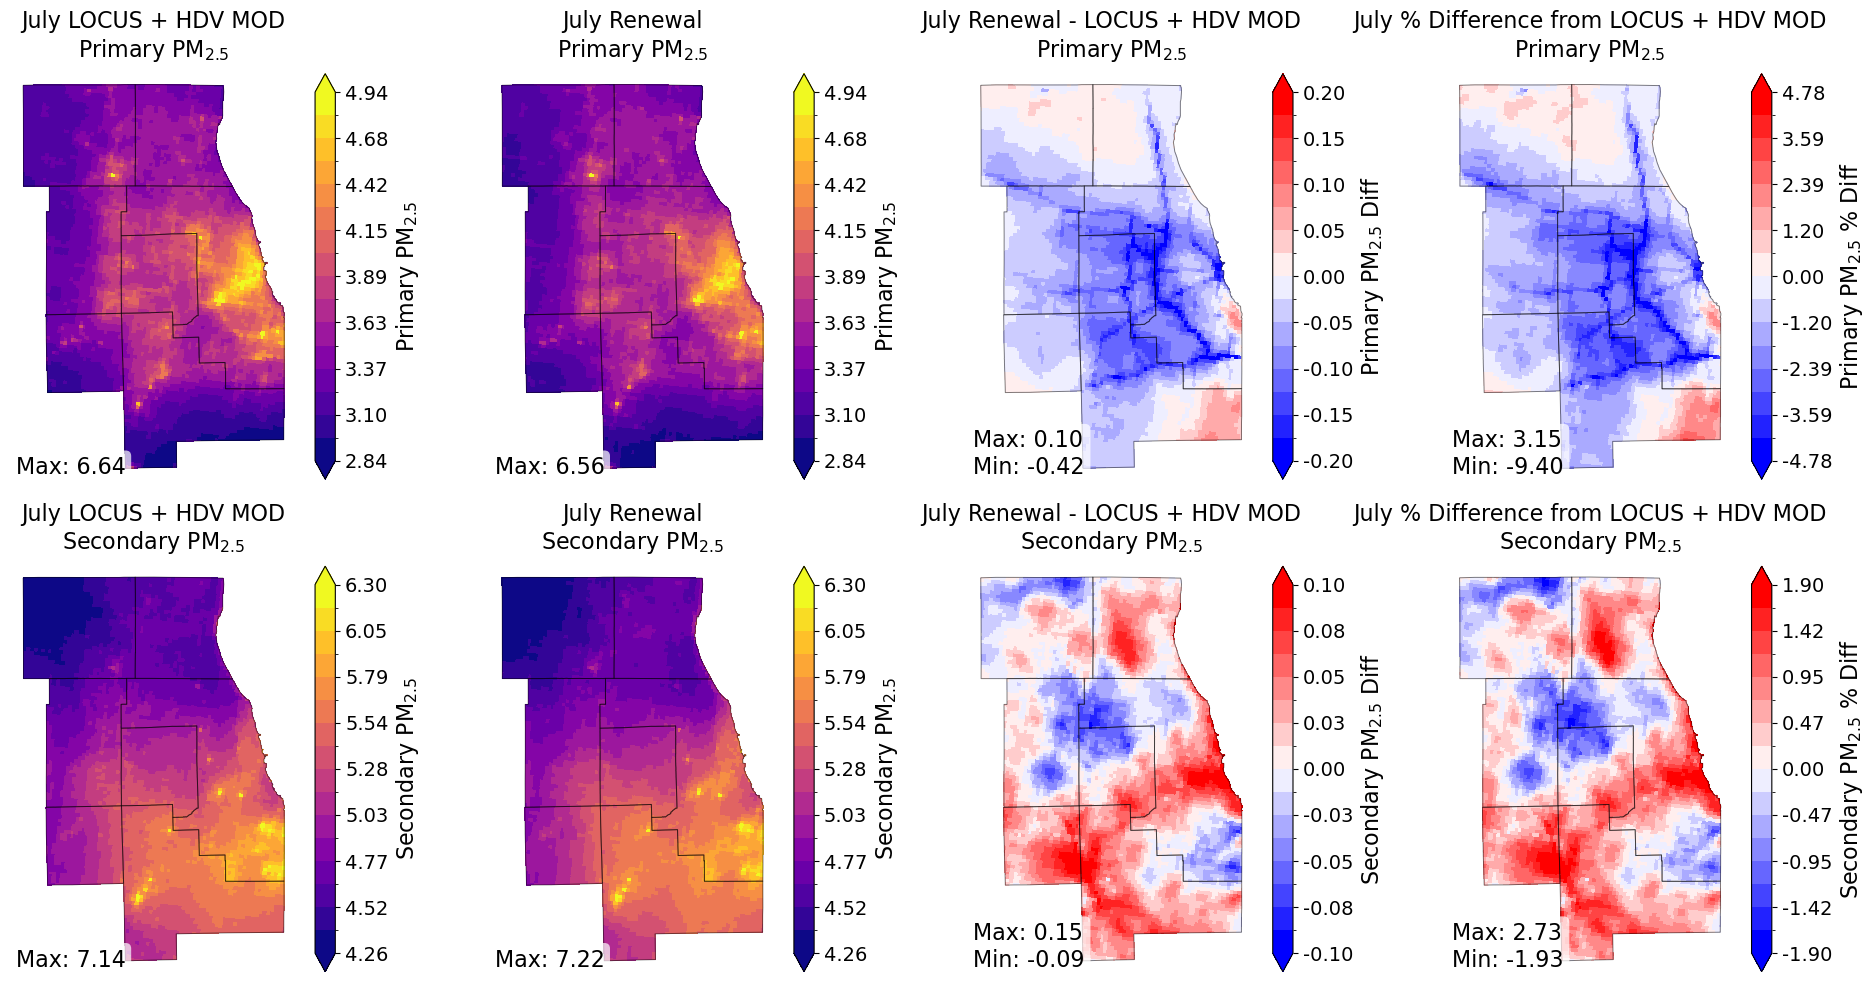

C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\343064728.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("plasma")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\343064728.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\343064728.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0,

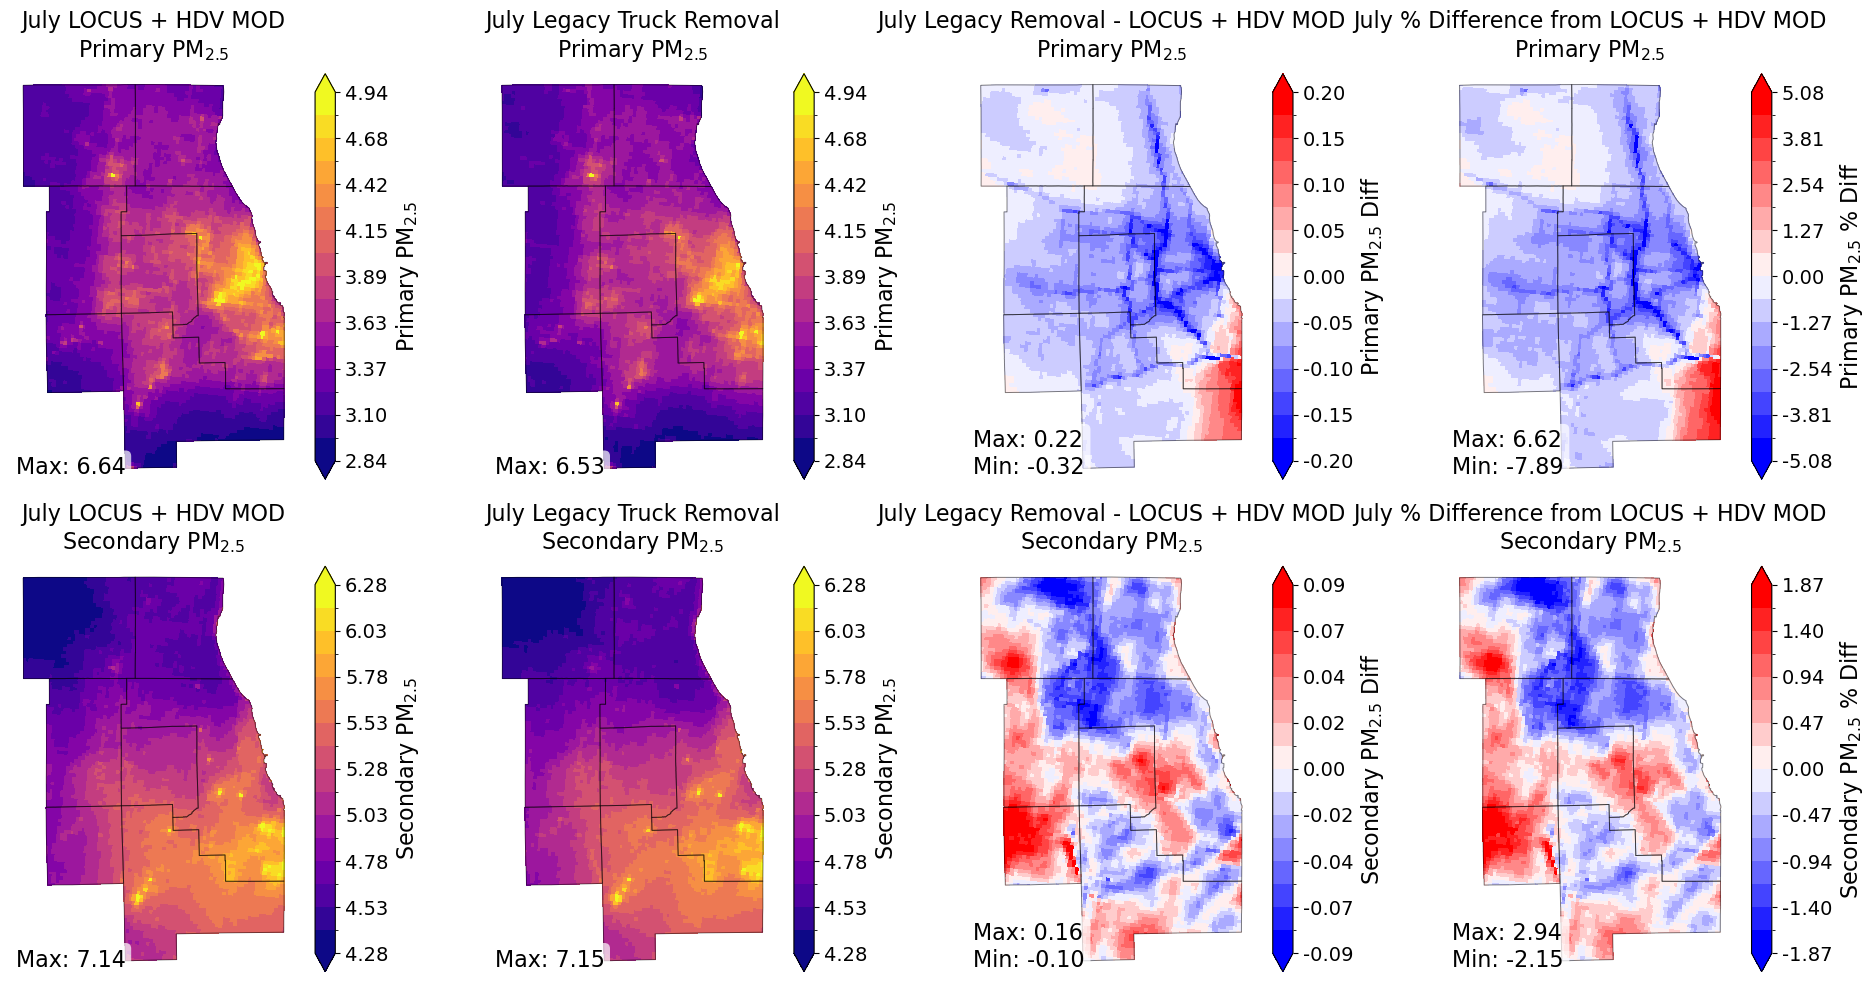

C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\343064728.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("plasma")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\343064728.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_16528\343064728.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0,

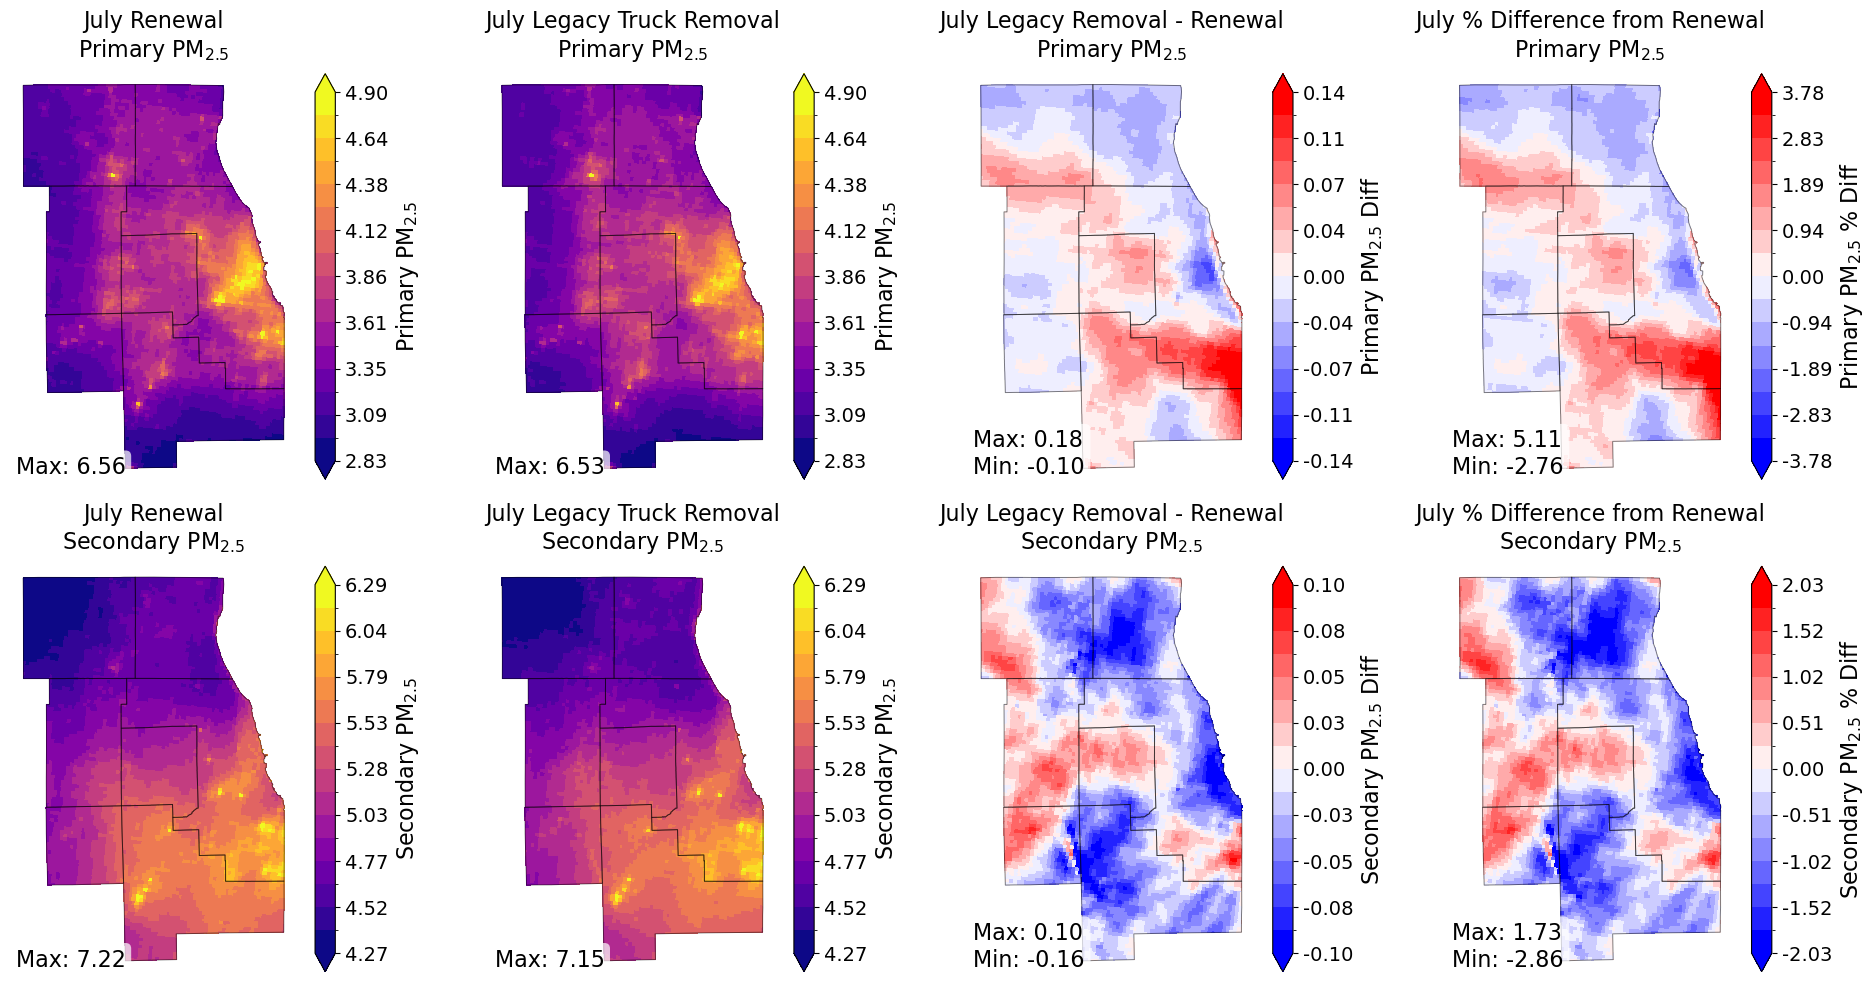

In [19]:
N_BINS = 16

pm_groups = {
    "PRIMARY_PM25": {
        "species": primary_pm_species,
        "title": "Primary PM$_{2.5}$",
        "label": "Primary PM$_{2.5}$"
    },
    "SECONDARY_PM25": {
        "species": secondary_pm_species,
        "title": "Secondary PM$_{2.5}$",
        "label": "Secondary PM$_{2.5}$"
    }
}

# ---------------------------------------------------
# Add primary and secondary PM2.5 columns to each scenario
# ---------------------------------------------------
scenario_source_gdfs = {
    "Base": cmap_base,
    "LOCUS + HDV MOD": cmap_idling,
    "Renewal": cmap_renewal,
    "Legacy Truck Removal": cmap_zeropre2010s
}

for scen_name, gdf in scenario_source_gdfs.items():
    for pm_name, cfg in pm_groups.items():
        missing = [sp for sp in cfg["species"] if sp not in gdf.columns]
        if missing:
            print(f"{scen_name}: missing {pm_name} species: {missing}")
        else:
            gdf[pm_name] = gdf[cfg["species"]].astype(float).sum(axis=1)

# ---------------------------------------------------
# Reusable plotting function
# ---------------------------------------------------
def plot_pm_comparison(gdf_a, gdf_b, name_a, name_b, diff_name, pct_ref_name):
    pollutants = ["PRIMARY_PM25", "SECONDARY_PM25"]

    # ---------------------------------------------------
    # absolute styles
    # ---------------------------------------------------
    abs_styles = {}

    for pol in pollutants:
        vals_all = []

        for gdf in [gdf_a, gdf_b]:
            vals = gdf[pol].astype(float).to_numpy()
            vals = vals[np.isfinite(vals)]
            vals_all.append(vals)

        vals_all = np.concatenate(vals_all)

        vmin = np.quantile(vals_all, 0.001)
        vmax = np.quantile(vals_all, 0.999)

        if np.isclose(vmin, vmax):
            vmax = vmin + 1e-6

        cmap_disc = ListedColormap(
            plt.cm.get_cmap("plasma")(np.linspace(0, 1, N_BINS))
        )
        bounds = np.linspace(vmin, vmax, N_BINS + 1)
        norm = BoundaryNorm(bounds, cmap_disc.N)

        abs_styles[pol] = {
            "bounds": bounds,
            "cmap": cmap_disc,
            "norm": norm
        }

    # ---------------------------------------------------
    # difference styles
    # ---------------------------------------------------
    diff_styles = {}

    for pol in pollutants:
        vals_a = gdf_a[pol].astype(float).to_numpy()
        vals_b = gdf_b[pol].astype(float).to_numpy()

        diff_vals = vals_b - vals_a
        pct_vals = np.where(vals_a != 0, (diff_vals / vals_a) * 100.0, np.nan)

        diff_vals_finite = diff_vals[np.isfinite(diff_vals)]
        pct_vals_finite = pct_vals[np.isfinite(pct_vals)]

        diff_lim = np.quantile(np.abs(diff_vals_finite), 0.99)
        pct_lim = np.quantile(np.abs(pct_vals_finite), 0.99)

        if np.isclose(diff_lim, 0):
            diff_lim = 1e-6
        if np.isclose(pct_lim, 0):
            pct_lim = 1e-6

        diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
        pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)

        diff_cmap = ListedColormap(
            plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
        )
        pct_cmap = ListedColormap(
            plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
        )

        diff_styles[pol] = {
            "diff_bounds": diff_bounds,
            "diff_cmap": diff_cmap,
            "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N),
            "pct_bounds": pct_bounds,
            "pct_cmap": pct_cmap,
            "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N)
        }

    # ---------------------------------------------------
    # make plotting GeoDataFrames
    # ---------------------------------------------------
    plot_a = gdf_a.copy()
    plot_b = gdf_b.copy()
    plot_diff = gdf_b.copy()
    plot_pct = gdf_b.copy()

    for pol in pollutants:
        plot_diff[pol] = gdf_b[pol].astype(float) - gdf_a[pol].astype(float)
        plot_pct[pol] = np.where(
            gdf_a[pol].astype(float) != 0,
            ((gdf_b[pol].astype(float) - gdf_a[pol].astype(float)) /
             gdf_a[pol].astype(float)) * 100.0,
            np.nan
        )

    scenario_gdfs = {
        name_a: plot_a,
        name_b: plot_b,
        diff_name: plot_diff,
        pct_ref_name: plot_pct
    }

    scenario_names = list(scenario_gdfs.keys())

    # ---------------------------------------------------
    # plot
    # ---------------------------------------------------
    fig, axs = plt.subplots(
        nrows=len(pollutants),
        ncols=4,
        figsize=(20, 10),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    for i, pol in enumerate(pollutants):
        for j, scen in enumerate(scenario_names):
            ax = axs[i, j]
            gdf = scenario_gdfs[scen]

            if j in [0, 1]:
                style = abs_styles[pol]
                cmap_disc = style["cmap"]
                norm = style["norm"]
                bounds = style["bounds"]
            elif j == 2:
                style = diff_styles[pol]
                cmap_disc = style["diff_cmap"]
                norm = style["diff_norm"]
                bounds = style["diff_bounds"]
            else:
                style = diff_styles[pol]
                cmap_disc = style["pct_cmap"]
                norm = style["pct_norm"]
                bounds = style["pct_bounds"]

            gdf.plot(
                column=pol,
                ax=ax,
                cmap=cmap_disc,
                norm=norm,
                edgecolor="none",
                antialiased=False
            )

            cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)

            #ax.set_title(f"{scen}: {pm_groups[pol]['title']}", fontsize=13)
            ax.set_title(
                    f"July {scen}\n{pm_groups[pol]['title']}",
                    fontsize=16
                )
            ax.set_axis_off()

            sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
            sm._A = []
            cbar = fig.colorbar(
                sm,
                ax=ax,
                fraction=0.046,
                pad=0.04,
                boundaries=bounds,
                ticks=bounds[::2],
                spacing="proportional",
                extend="both"
            )
            # make tick labels larger
            cbar.ax.tick_params(labelsize=14)

            # round tick labels to 2 decimal places
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        
            if j == 3:
                cbar.set_label(f"{pm_groups[pol]['label']} % Diff", fontsize=16)
            elif j == 2:
                cbar.set_label(f"{pm_groups[pol]['label']} Diff", fontsize=16)
            else:
                cbar.set_label(pm_groups[pol]["label"], fontsize=16)

            vals = gdf[pol].astype(float).to_numpy()
            vals = vals[np.isfinite(vals)]

            vmax_panel = float(np.nanmax(vals))
            vmin_panel = float(np.nanmin(vals))

            if j in [0, 1]:
                annot_text = f"Max: {vmax_panel:.2f}"
            else:
                annot_text = f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"

            ax.text(
                0.02, 0.02,
                annot_text,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=16,
                color="black",
                bbox=dict(
                    facecolor="white",
                    alpha=0.7,
                    boxstyle="round,pad=0.25",
                    linewidth=0
                )
            )

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------
# 1. Base vs LOCUS + HDV
# ---------------------------------------------------
plot_pm_comparison(
    gdf_a=cmap_base,
    gdf_b=cmap_idling,
    name_a="Base",
    name_b="LOCUS + HDV MOD",
    diff_name="LOCUS + HDV MOD - Base",
    pct_ref_name="% Difference from Base"
)

# ---------------------------------------------------
# 2. LOCUS + HDV vs Renewal
# ---------------------------------------------------
plot_pm_comparison(
    gdf_a=cmap_idling,
    gdf_b=cmap_renewal,
    name_a="LOCUS + HDV MOD",
    name_b="Renewal",
    diff_name="Renewal - LOCUS + HDV MOD",
    pct_ref_name="% Difference from LOCUS + HDV MOD"
)

# ---------------------------------------------------
# 3. LOCUS + HDV vs Zero Legacy
# ---------------------------------------------------
plot_pm_comparison(
    gdf_a=cmap_idling,
    gdf_b=cmap_zeropre2010s,
    name_a="LOCUS + HDV MOD",
    name_b="Legacy Truck Removal",
    diff_name="Legacy Removal - LOCUS + HDV MOD",
    pct_ref_name="% Difference from LOCUS + HDV MOD"
)

# ---------------------------------------------------
# 4. Renewal vs Zero Legacy
# ---------------------------------------------------
plot_pm_comparison(
    gdf_a=cmap_renewal,
    gdf_b=cmap_zeropre2010s,
    name_a="Renewal",
    name_b="Legacy Truck Removal",
    diff_name="Legacy Removal - Renewal",
    pct_ref_name="% Difference from Renewal"
)